In [3]:
!pip install neurom

  Using cached neurom-4.0.5.tar.gz (536 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 47.9 MB/s eta 0:00:00
  Created wheel for neurom: filename=neurom-4.0.5-py3-none-any.whl size=110130 sha256=9ad189173284a4cdae654ef4376ffe272ccf78f9514421c5b2aa5e0217a1e0c7
  Stored in directory: /root/.cache/pip/wheels/14/2c/59/1af8bbdd92bc14980684dcba369e060a97a2f82ba9b7ca0cc0
Successfully built neurom


In [4]:
import neurom as nm
from neurom.view import plot_morph, plot_morph3d, plot_dendrogram
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [6]:
import zipfile
import os

zip_path = '/content/ASSIP_Full_Control_Metadata.zip'
extract_to = '/content/ASSIP_Full_Control_Metadata'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipping complete!")

Unzipping complete!


In [7]:
zip_path = '/content/ASSIP_Full_Control_SWC.zip'
extract_to = '/content/ASSIP_Full_Control_SWC'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipping complete!")

Unzipping complete!


In [8]:
zip_path = '/content/ASSIP_Full_AD_SWC.zip'
extract_to = '/content/ASSIP_Full_AD_SWC'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipping complete!")

Unzipping complete!


In [9]:
zip_path = '/content/ASSIP_Full_AD_Metadata.zip'
extract_to = '/content/ASSIP_Full_AD_Metadata'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipping complete!")

Unzipping complete!


In [10]:
AD_PATH = '/content/ASSIP_Full_AD_SWC/ASSIP_Full_AD_SWC'
CONTROL_PATH = '/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC'

ad_files = [os.path.join(AD_PATH, f)
            for f in os.listdir(AD_PATH)
            if f.lower().endswith('.swc')]

control_files = [os.path.join(CONTROL_PATH, f)
                 for f in os.listdir(CONTROL_PATH)
                 if f.lower().endswith('.swc')]

print('AD files:', len(ad_files))
print('Control files:', len(control_files))

AD files: 1176
Control files: 4859


In [11]:
all_files = [(f, 'AD') for f in ad_files] + [(f, 'Control') for f in control_files]

In [12]:
from neurom.core.soma import SomaError

data = []
skipped_files = []

for filepath, label in all_files:
    try:
        m = nm.load_morphology(filepath)
    except (AssertionError, SomaError) as e:
        skipped_files.append({'name': os.path.basename(filepath), 'group': label, 'error': str(e)})
        continue
    local_bif_angles = []
    for s in nm.iter_sections(m):
        if len(s.children) == 2:
            angle = nm.features.bifurcation.local_bifurcation_angle(s)
            local_bif_angles.append(angle)

    mean_local_bif_angle = np.mean(local_bif_angles) if local_bif_angles else 0

    soma_vol = nm.features.morphology.soma_volume(m)
    soma_area = nm.features.morphology.soma_surface_area(m)
    soma_rad = nm.features.morphology.soma_radius(m)

    num_neurites = nm.get('number_of_neurites', m)
    num_sections = nm.get('number_of_sections', m)
    num_segments = nm.get('number_of_segments', m)

    sec_lengths = nm.get('section_lengths', m)
    seg_lengths = nm.get('segment_lengths', m)

    mean_sec_len = np.mean(sec_lengths) if sec_lengths else 0
    mean_seg_len = np.mean(seg_lengths) if seg_lengths else 0

    n_bifs = sum(1 for s in nm.iter_sections(m) if len(s.children) == 2)

    data.append({
        'neuron_name': os.path.basename(filepath),
        'group': label,
        'soma_volume': soma_vol if soma_vol is not None else np.nan,
        'soma_surface_area': soma_area if soma_area is not None else np.nan,
        'soma_radius': soma_rad if soma_rad is not None else np.nan,
        'number_of_neurites': num_neurites if num_neurites is not None else np.nan,
        'number_of_sections': num_sections if num_sections is not None else np.nan,
        'number_of_segments': num_segments if num_segments is not None else np.nan,
        'mean_section_length': mean_sec_len if mean_sec_len is not None else np.nan,
        'mean_segment_length': mean_seg_len if mean_seg_len is not None else np.nan,
        'mean_local_bif_angle': mean_local_bif_angle if mean_local_bif_angle is not None else np.nan,
        'n_bifs': n_bifs if n_bifs is not None else np.nan
    })

print(f"Successfully loaded: {len(data)} neurons")
print(f"Total skipped: {len(skipped_files)}\n")
for s in skipped_files:
    print(f"  [{s['group']}] {s['name']} — {s['error']}")

/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:352: UserWarning: Approximating soma volume by a sphere. <morphio._morphio.Soma object at 0x7ac7634f7e30>
  warnings.warn('Approximating soma volume by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:310: UserWarning: Approximating soma area by a sphere. <morphio._morphio.Soma object at 0x7ac7634f7e30>
  warnings.warn('Approximating soma area by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:352: UserWarning: Approximating soma volume by a sphere. <morphio._morphio.Soma object at 0x7ac763bfecf0>
  warnings.warn('Approximating soma volume by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:310: UserWarning: Approximating soma area by a sphere. <morphio._morphio.Soma object at 0x7ac763bfecf0>
  warnings.warn('Approximating soma area by a sphere. {}'.format(morphio_soma))
/usr/local/lib/p

Successfully loaded: 6010 neurons
Total skipped: 25

  [Control] Kyrargyri_Attwell_C2-11.CNG.swc — 
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/Kyrargyri_Attwell_C2-11.CNG.swc:3:error

Found soma bifurcation
The following children have been found:
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/Kyrargyri_Attwell_C2-11.CNG.swc:4:warning


/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/Kyrargyri_Attwell_C2-11.CNG.swc:59:warning


  [Control] Kyrargyri_Attwell_C2-10.CNG.swc — 
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/Kyrargyri_Attwell_C2-10.CNG.swc:14:error

Found soma bifurcation
The following children have been found:
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/Kyrargyri_Attwell_C2-10.CNG.swc:15:warning


/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/Kyrargyri_Attwell_C2-10.CNG.swc:40:warning


  [Control] 3DDS_6_VK.CNG.swc — 
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/3DDS_6_VK.CNG.swc:3:error

Found soma bifurcati

In [13]:
df = pd.DataFrame(data)

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
df.to_excel('/content/drive/MyDrive/ASSIP_2025/Neuron_Metrics_Report_725.xlsx', index=False)

In [16]:
metrics = ['soma_volume', 'soma_surface_area', 'soma_radius',
           'number_of_neurites', 'number_of_sections', 'number_of_segments',
           'mean_section_length', 'mean_segment_length', 'mean_local_bif_angle', 'n_bifs']

In [17]:
# ── LOAD METADATA ─────────────────────────────────────────────────────────────
def load_metadata_from_folder(folder_path, group_label):
    all_metadata = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".csv"):
            neuron_name = filename.replace(".csv", "")
            file_path = os.path.join(folder_path, filename)
            df2 = pd.read_csv(file_path)
            df2["neuron_name"] = neuron_name
            df2["group"] = group_label
            all_metadata.append(df2)
    return pd.concat(all_metadata, ignore_index=True)

ad_folder = "/content/ASSIP_Full_AD_Metadata/ASSIP_Full_AD_Metadata"
ctrl_folder = "/content/ASSIP_Full_Control_Metadata/ASSIP_Full_Control_Metadata"

ad_metadata = load_metadata_from_folder(ad_folder, group_label="AD")
ctrl_metadata = load_metadata_from_folder(ctrl_folder, group_label="Control")
combined_metadata = pd.concat([ad_metadata, ctrl_metadata], ignore_index=True)

In [18]:
# ── CLEAN METADATA ────────────────────────────────────────────────────────────
skipped_file_names = [s['name'] for s in skipped_files]
skipped_files_cleaned = [name.replace('.CNG', '') for name in skipped_file_names]

combined_metadata['neuron_name'] = combined_metadata['neuron_name'].str.replace('_metadata$', '.swc', regex=True)
filtered_metadata = combined_metadata[~combined_metadata['neuron_name'].isin(skipped_files_cleaned)].copy()
filtered_metadata_clean = filtered_metadata.dropna(axis=1, how='any')

In [19]:
# ── MERGE MORPHOMETRY WITH METADATA ──────────────────────────────────────────
df['neuron_name'] = df['neuron_name'].str.replace('.CNG.swc', '.swc', regex=False)

merged_df = df.merge(filtered_metadata_clean, on='neuron_name')

are_groups_equal = (merged_df['group_x'] == merged_df['group_y']).all()
if are_groups_equal:
    merged_df = merged_df.drop(columns='group_y')
    merged_df = merged_df.rename(columns={'group_x': 'group'})

In [41]:
# ── CREATE ADULT-ONLY COHORT ──────────────────────────────────────────────────
adult_df = merged_df[
    (merged_df['age_classification'] == 'adult') &
    (merged_df['gender'] != 'Male/Female')
].copy()

print("Adult cohort size per group:")
print(adult_df.groupby('group').size())

Adult cohort size per group:
group
AD         1176
Control    2642
dtype: int64


In [40]:
# ── REMOVE OUTLIERS ───────────────────────────────────────────────────────────
from scipy.stats import zscore

z_scores = adult_df[metrics].apply(zscore)
adult_df_no_outliers = adult_df[(z_scores.abs() <= 3).all(axis=1)]

print("After outlier removal:")
print(adult_df_no_outliers.groupby('group').size())

After outlier removal:
group
AD         1172
Control    4537
dtype: int64


In [42]:
# ── BALANCE CLASSES ───────────────────────────────────────────────────────────
adult_df = adult_df.dropna(subset=metrics + ['group']).copy()
adult_df['label'] = adult_df['group'].map({'Control': 0, 'AD': 1})

ad_df = adult_df[adult_df['label'] == 1]
control_df = adult_df[adult_df['label'] == 0]

RANDOM_SEED = 42
control_downsampled = control_df.sample(n=len(ad_df), random_state=RANDOM_SEED)
df_balanced = pd.concat([ad_df, control_downsampled], axis=0).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

X = df_balanced[metrics]
y = df_balanced['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Balanced shape:", df_balanced.shape)
print("Value counts:\n", y.value_counts())

Balanced shape: (2352, 46)
Value counts:
 label
0    1176
1    1176
Name: count, dtype: int64


In [43]:
# ── REMOVE OUTLIERS FROM BALANCED DATASET ─────────────────────────────────────
z_scores2 = df_balanced[metrics].apply(zscore)
filtered_no_outliers_balanced = df_balanced[(z_scores2.abs() <= 3).all(axis=1)]

In [48]:
from scipy.stats import ttest_ind

n_tests = 20

print("Unbalanced Dataset")
for metric in metrics:
    group1 = adult_df_no_outliers[adult_df_no_outliers['group'] == 'Control'][metric]
    group2 = adult_df_no_outliers[adult_df_no_outliers['group'] == 'AD'][metric]

    stat, p_value = ttest_ind(group1, group2, equal_var=False)

    # Simple Bonferroni multiplication
    adjusted_p = min(p_value * n_tests, 1.0)

    print(f"{metric}: t = {stat:.3f}, Adjusted p = {adjusted_p:.4f}")

print("Balanced Dataset")
for metric in metrics:
    group1 = filtered_no_outliers_balanced[filtered_no_outliers_balanced['group'] == 'Control'][metric]
    group2 = filtered_no_outliers_balanced[filtered_no_outliers_balanced['group'] == 'AD'][metric]

    stat, p_value = ttest_ind(group1, group2, equal_var=False)

    # Simple Bonferroni multiplication
    adjusted_p = min(p_value * n_tests, 1.0)

    print(f"{metric}: t = {stat:.3f}, Adjusted p = {adjusted_p:.4f}")

Unbalanced Dataset
soma_volume: t = 17.910, Adjusted p = 0.0000
soma_surface_area: t = 22.555, Adjusted p = 0.0000
soma_radius: t = 18.830, Adjusted p = 0.0000
number_of_neurites: t = 4.084, Adjusted p = 0.0009
number_of_sections: t = 21.206, Adjusted p = 0.0000
number_of_segments: t = 10.388, Adjusted p = 0.0000
mean_section_length: t = -15.556, Adjusted p = 0.0000
mean_segment_length: t = 19.376, Adjusted p = 0.0000
mean_local_bif_angle: t = 21.769, Adjusted p = 0.0000
n_bifs: t = 21.198, Adjusted p = 0.0000
Balanced Dataset
soma_volume: t = 9.748, Adjusted p = 0.0000
soma_surface_area: t = 9.780, Adjusted p = 0.0000
soma_radius: t = 6.178, Adjusted p = 0.0000
number_of_neurites: t = 1.810, Adjusted p = 1.0000
number_of_sections: t = 15.346, Adjusted p = 0.0000
number_of_segments: t = 14.661, Adjusted p = 0.0000
mean_section_length: t = -11.317, Adjusted p = 0.0000
mean_segment_length: t = 3.792, Adjusted p = 0.0032
mean_local_bif_angle: t = 4.778, Adjusted p = 0.0000
n_bifs: t = 15.

In [36]:
def clean_metric_name(name):
    if name == 'n_bifs':
        name = 'Number_of_Bifurcations'
    elif name == 'mean_local_bif_angle':
        name = 'Mean_Local_Bifurcation_Angles'
    else:
        name = name.replace('bif', 'bifurcation')

    name = name.replace('_', ' ').title().replace(' Of ', ' of ')
    return name

/tmp/ipykernel_1157/2995472362.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=adult_df_no_outliers, palette='Set2', showfliers=False)


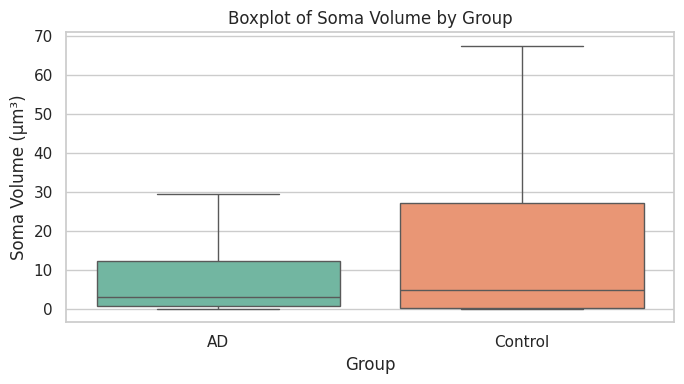

/tmp/ipykernel_1157/2995472362.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=adult_df_no_outliers, palette='Set2', showfliers=False)


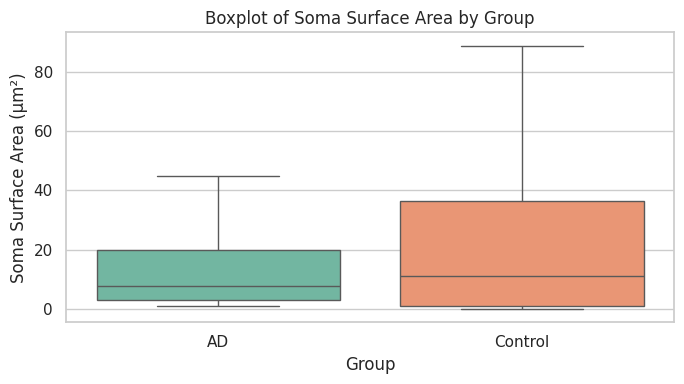

/tmp/ipykernel_1157/2995472362.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=adult_df_no_outliers, palette='Set2', showfliers=False)


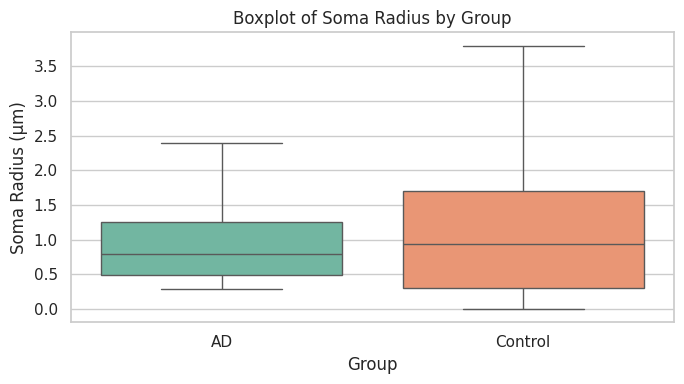

/tmp/ipykernel_1157/2995472362.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=adult_df_no_outliers, palette='Set2', showfliers=False)


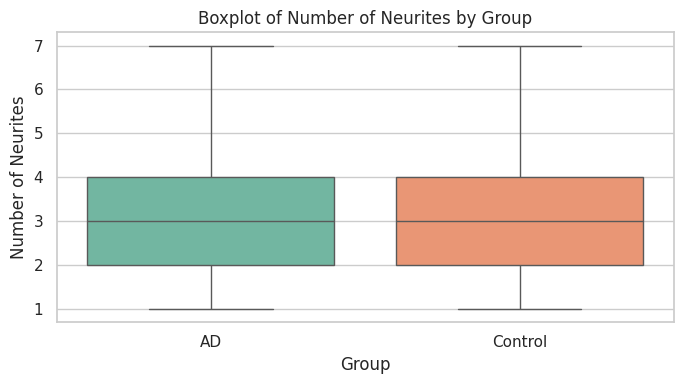

/tmp/ipykernel_1157/2995472362.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=adult_df_no_outliers, palette='Set2', showfliers=False)


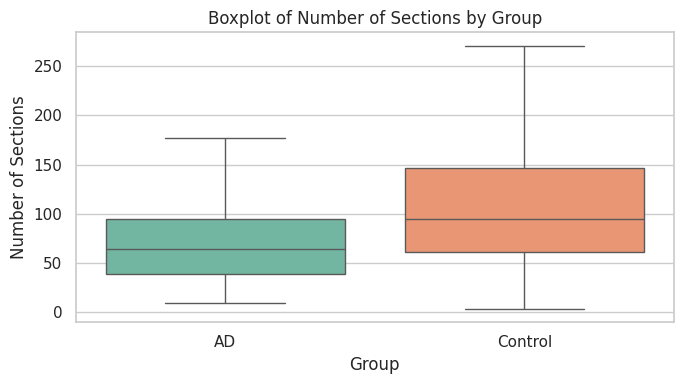

/tmp/ipykernel_1157/2995472362.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=adult_df_no_outliers, palette='Set2', showfliers=False)


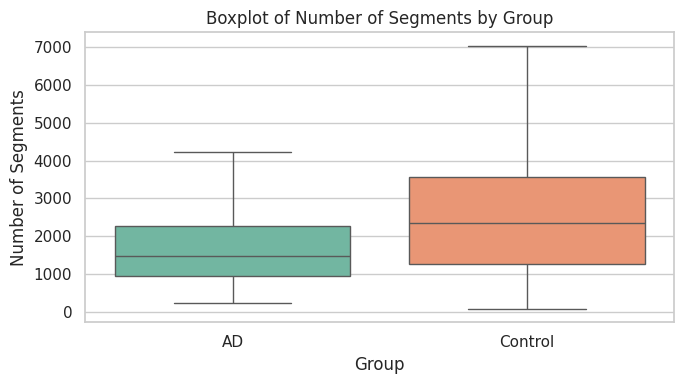

/tmp/ipykernel_1157/2995472362.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=adult_df_no_outliers, palette='Set2', showfliers=False)


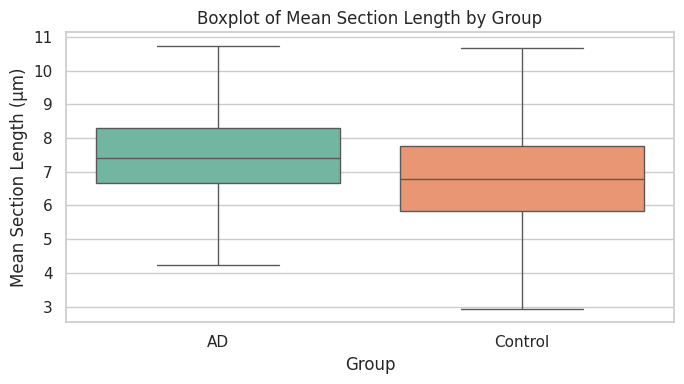

/tmp/ipykernel_1157/2995472362.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=adult_df_no_outliers, palette='Set2', showfliers=False)


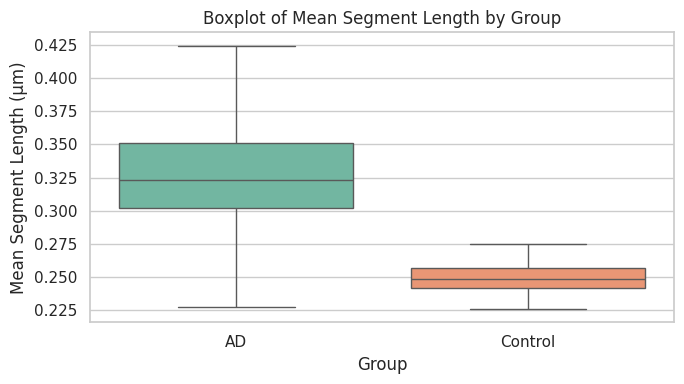

/tmp/ipykernel_1157/2995472362.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=adult_df_no_outliers, palette='Set2', showfliers=False)


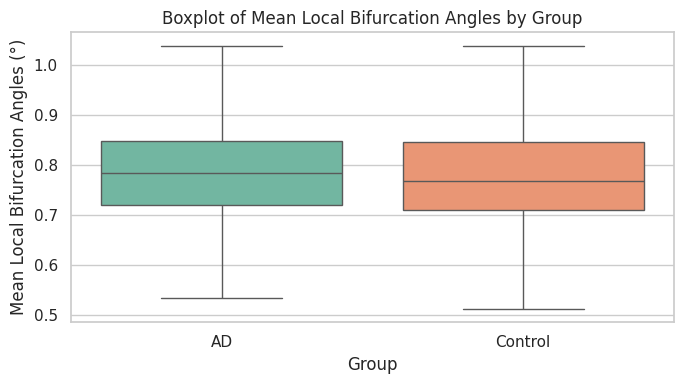

/tmp/ipykernel_1157/2995472362.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=adult_df_no_outliers, palette='Set2', showfliers=False)


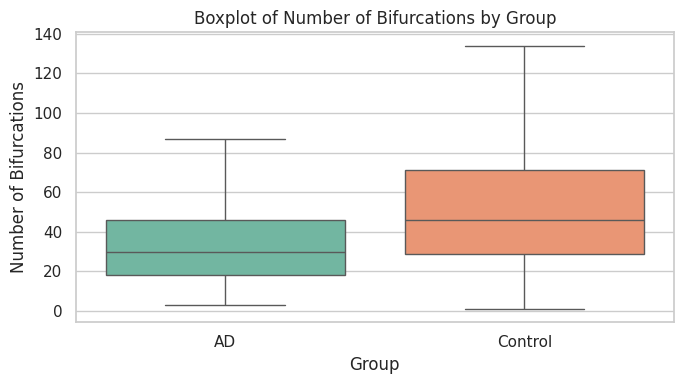

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')

metric_units = {
    'soma_volume': 'µm³',
    'soma_surface_area': 'µm²',
    'soma_radius': 'µm',
    'number_of_neurites': None,
    'number_of_sections': None,
    'number_of_segments': None,
    'mean_section_length': 'µm',
    'mean_segment_length': 'µm',
    'mean_local_bif_angle': '°',
    'n_bifs': None
}

for metric in metrics:
    clean_name = clean_metric_name(metric)
    unit = metric_units.get(metric)
    y_label = f'{clean_name} ({unit})' if unit else clean_name

    plt.figure(figsize=(7, 4))
    sns.boxplot(x='group', y=metric, data=adult_df_no_outliers, palette='Set2', showfliers=False)
    plt.xlabel('Group')
    plt.ylabel(y_label)
    plt.title(f'Boxplot of {clean_name} by Group')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1157/4285937113.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=30, title_fontsize=35)


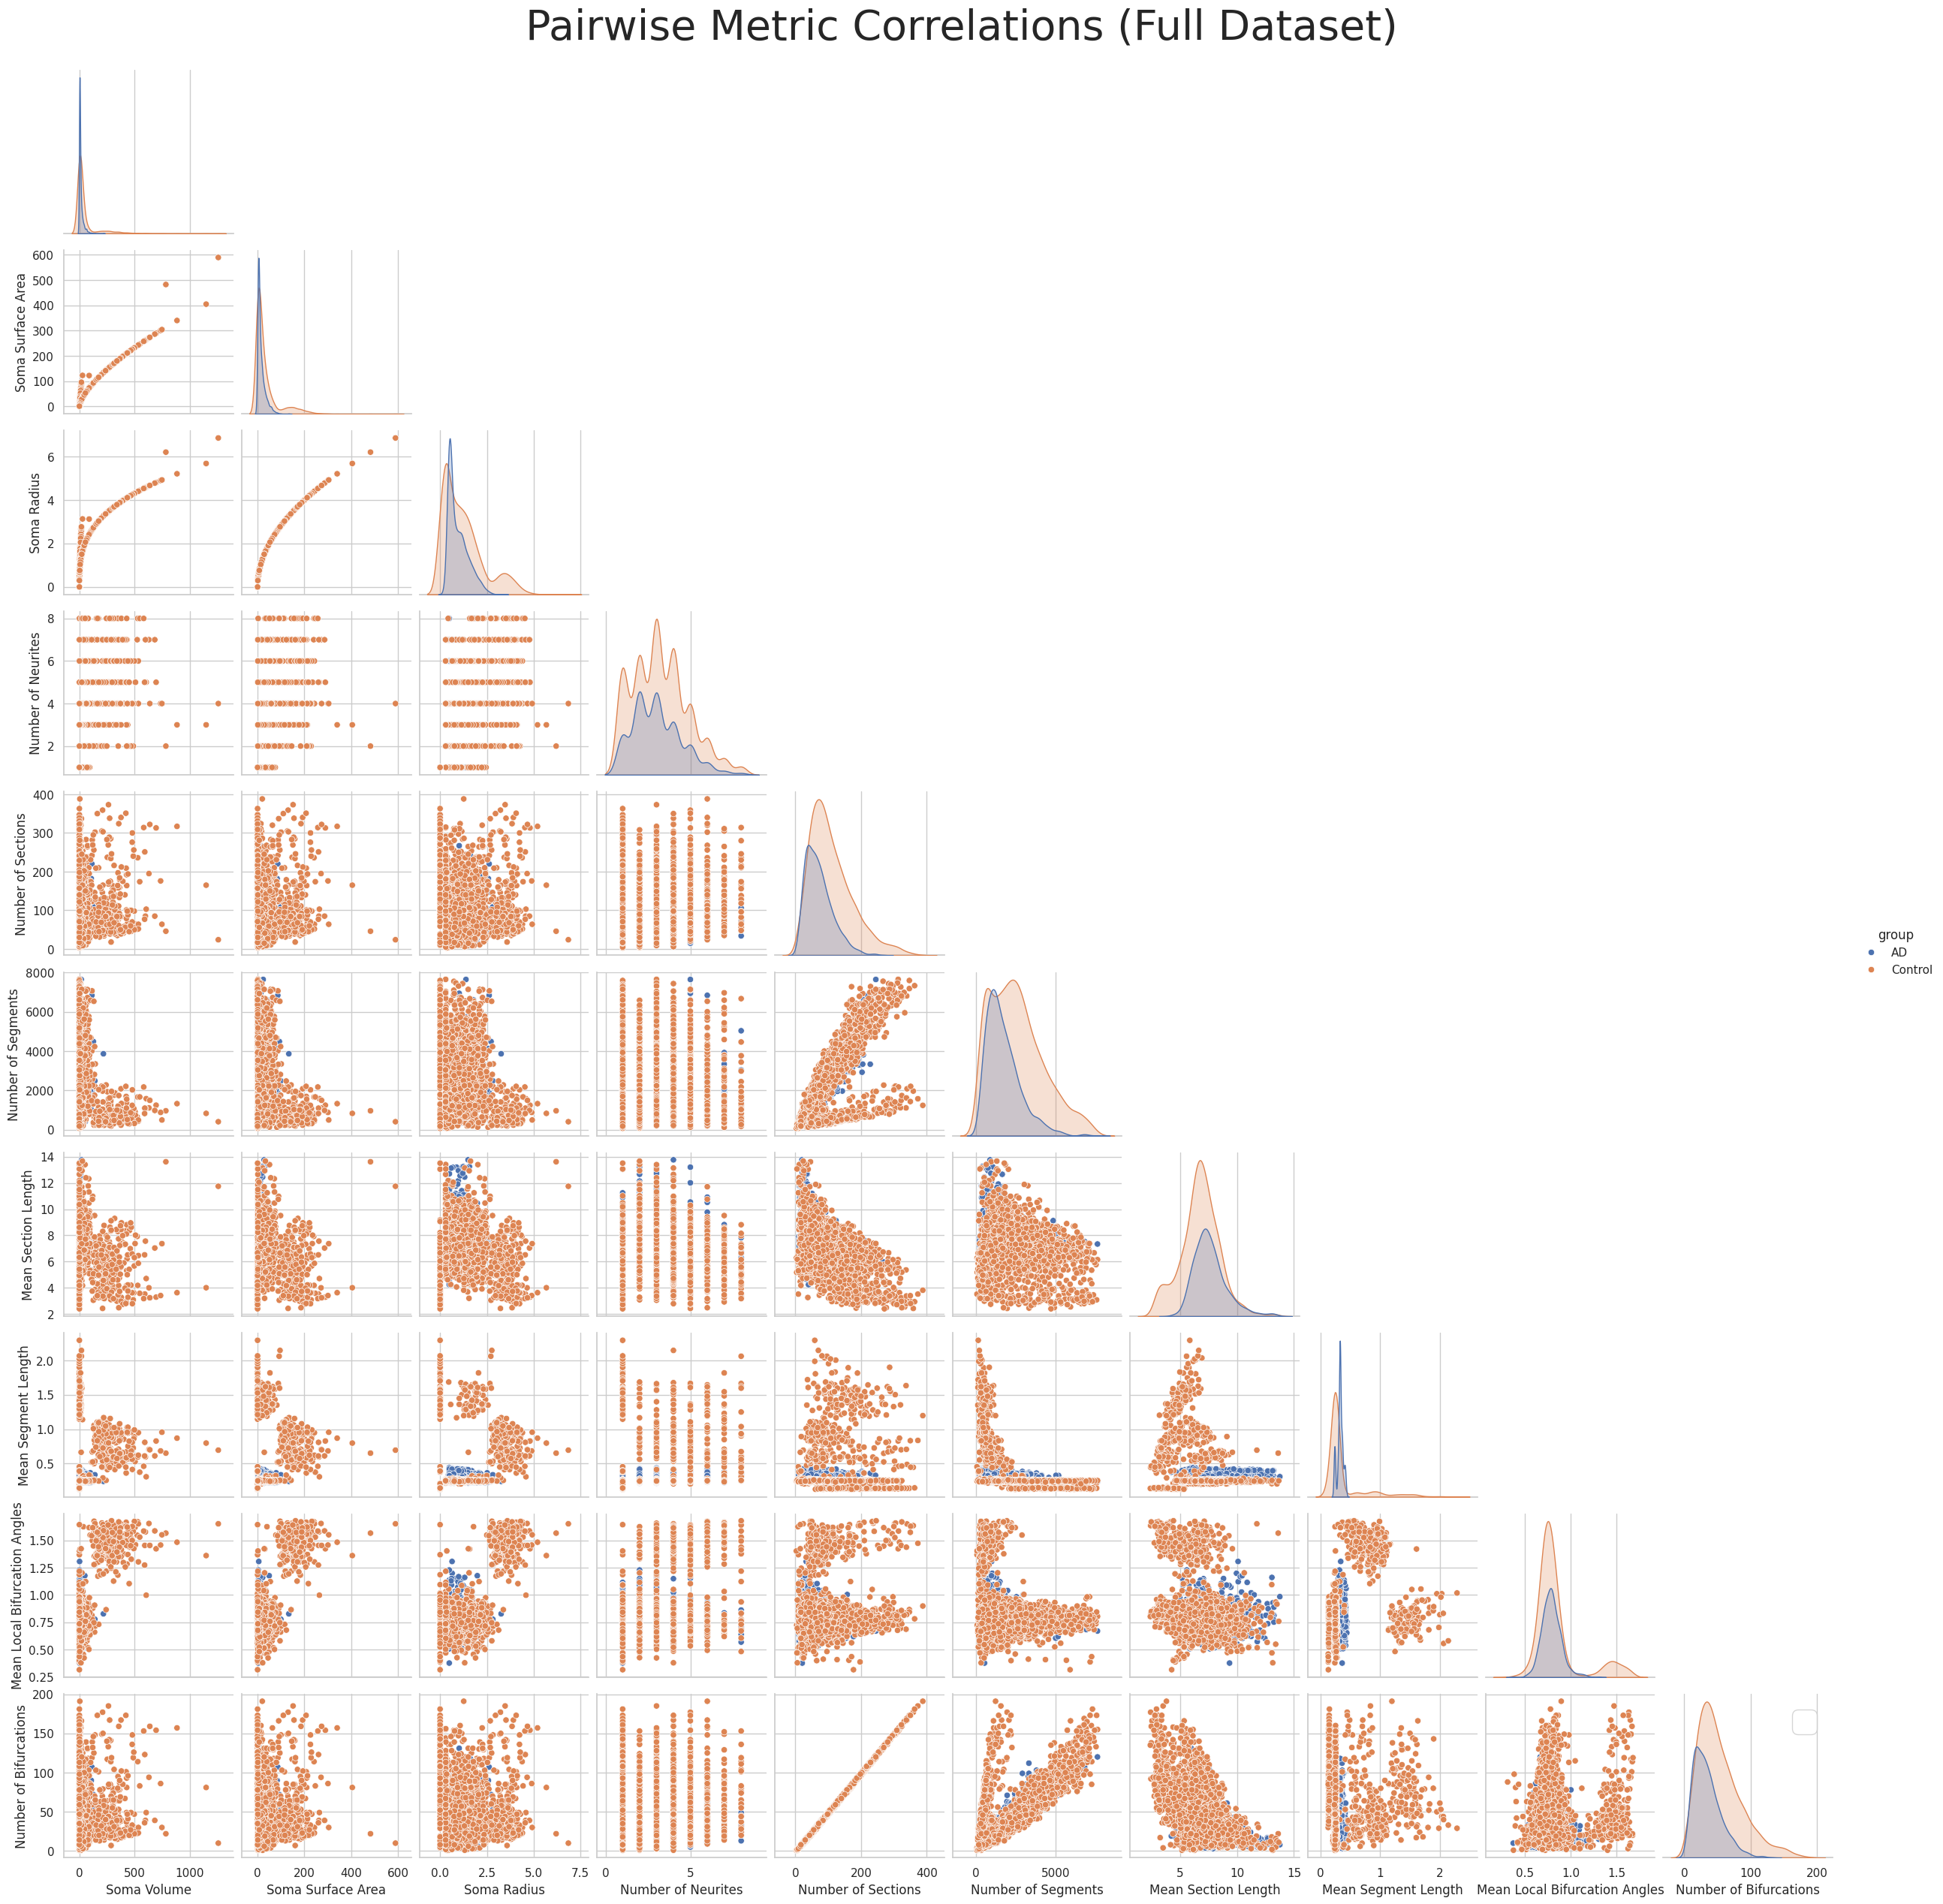

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = adult_df_no_outliers[metrics + ['group']].copy()

cleaned_metrics_map = {m: clean_metric_name(m) for m in metrics}
df_plot = df_plot.rename(columns=cleaned_metrics_map)

cleaned_metrics = [clean_metric_name(m) for m in metrics]

sns.pairplot(df_plot[cleaned_metrics + ['group']], hue='group', diag_kind='kde', corner=True)
plt.suptitle('Pairwise Metric Correlations (Full Dataset)', y=1.02, fontsize = 40)
plt.legend(fontsize=30, title_fontsize=35)
plt.show()

/tmp/ipykernel_1157/3460736544.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=30, title_fontsize=35)


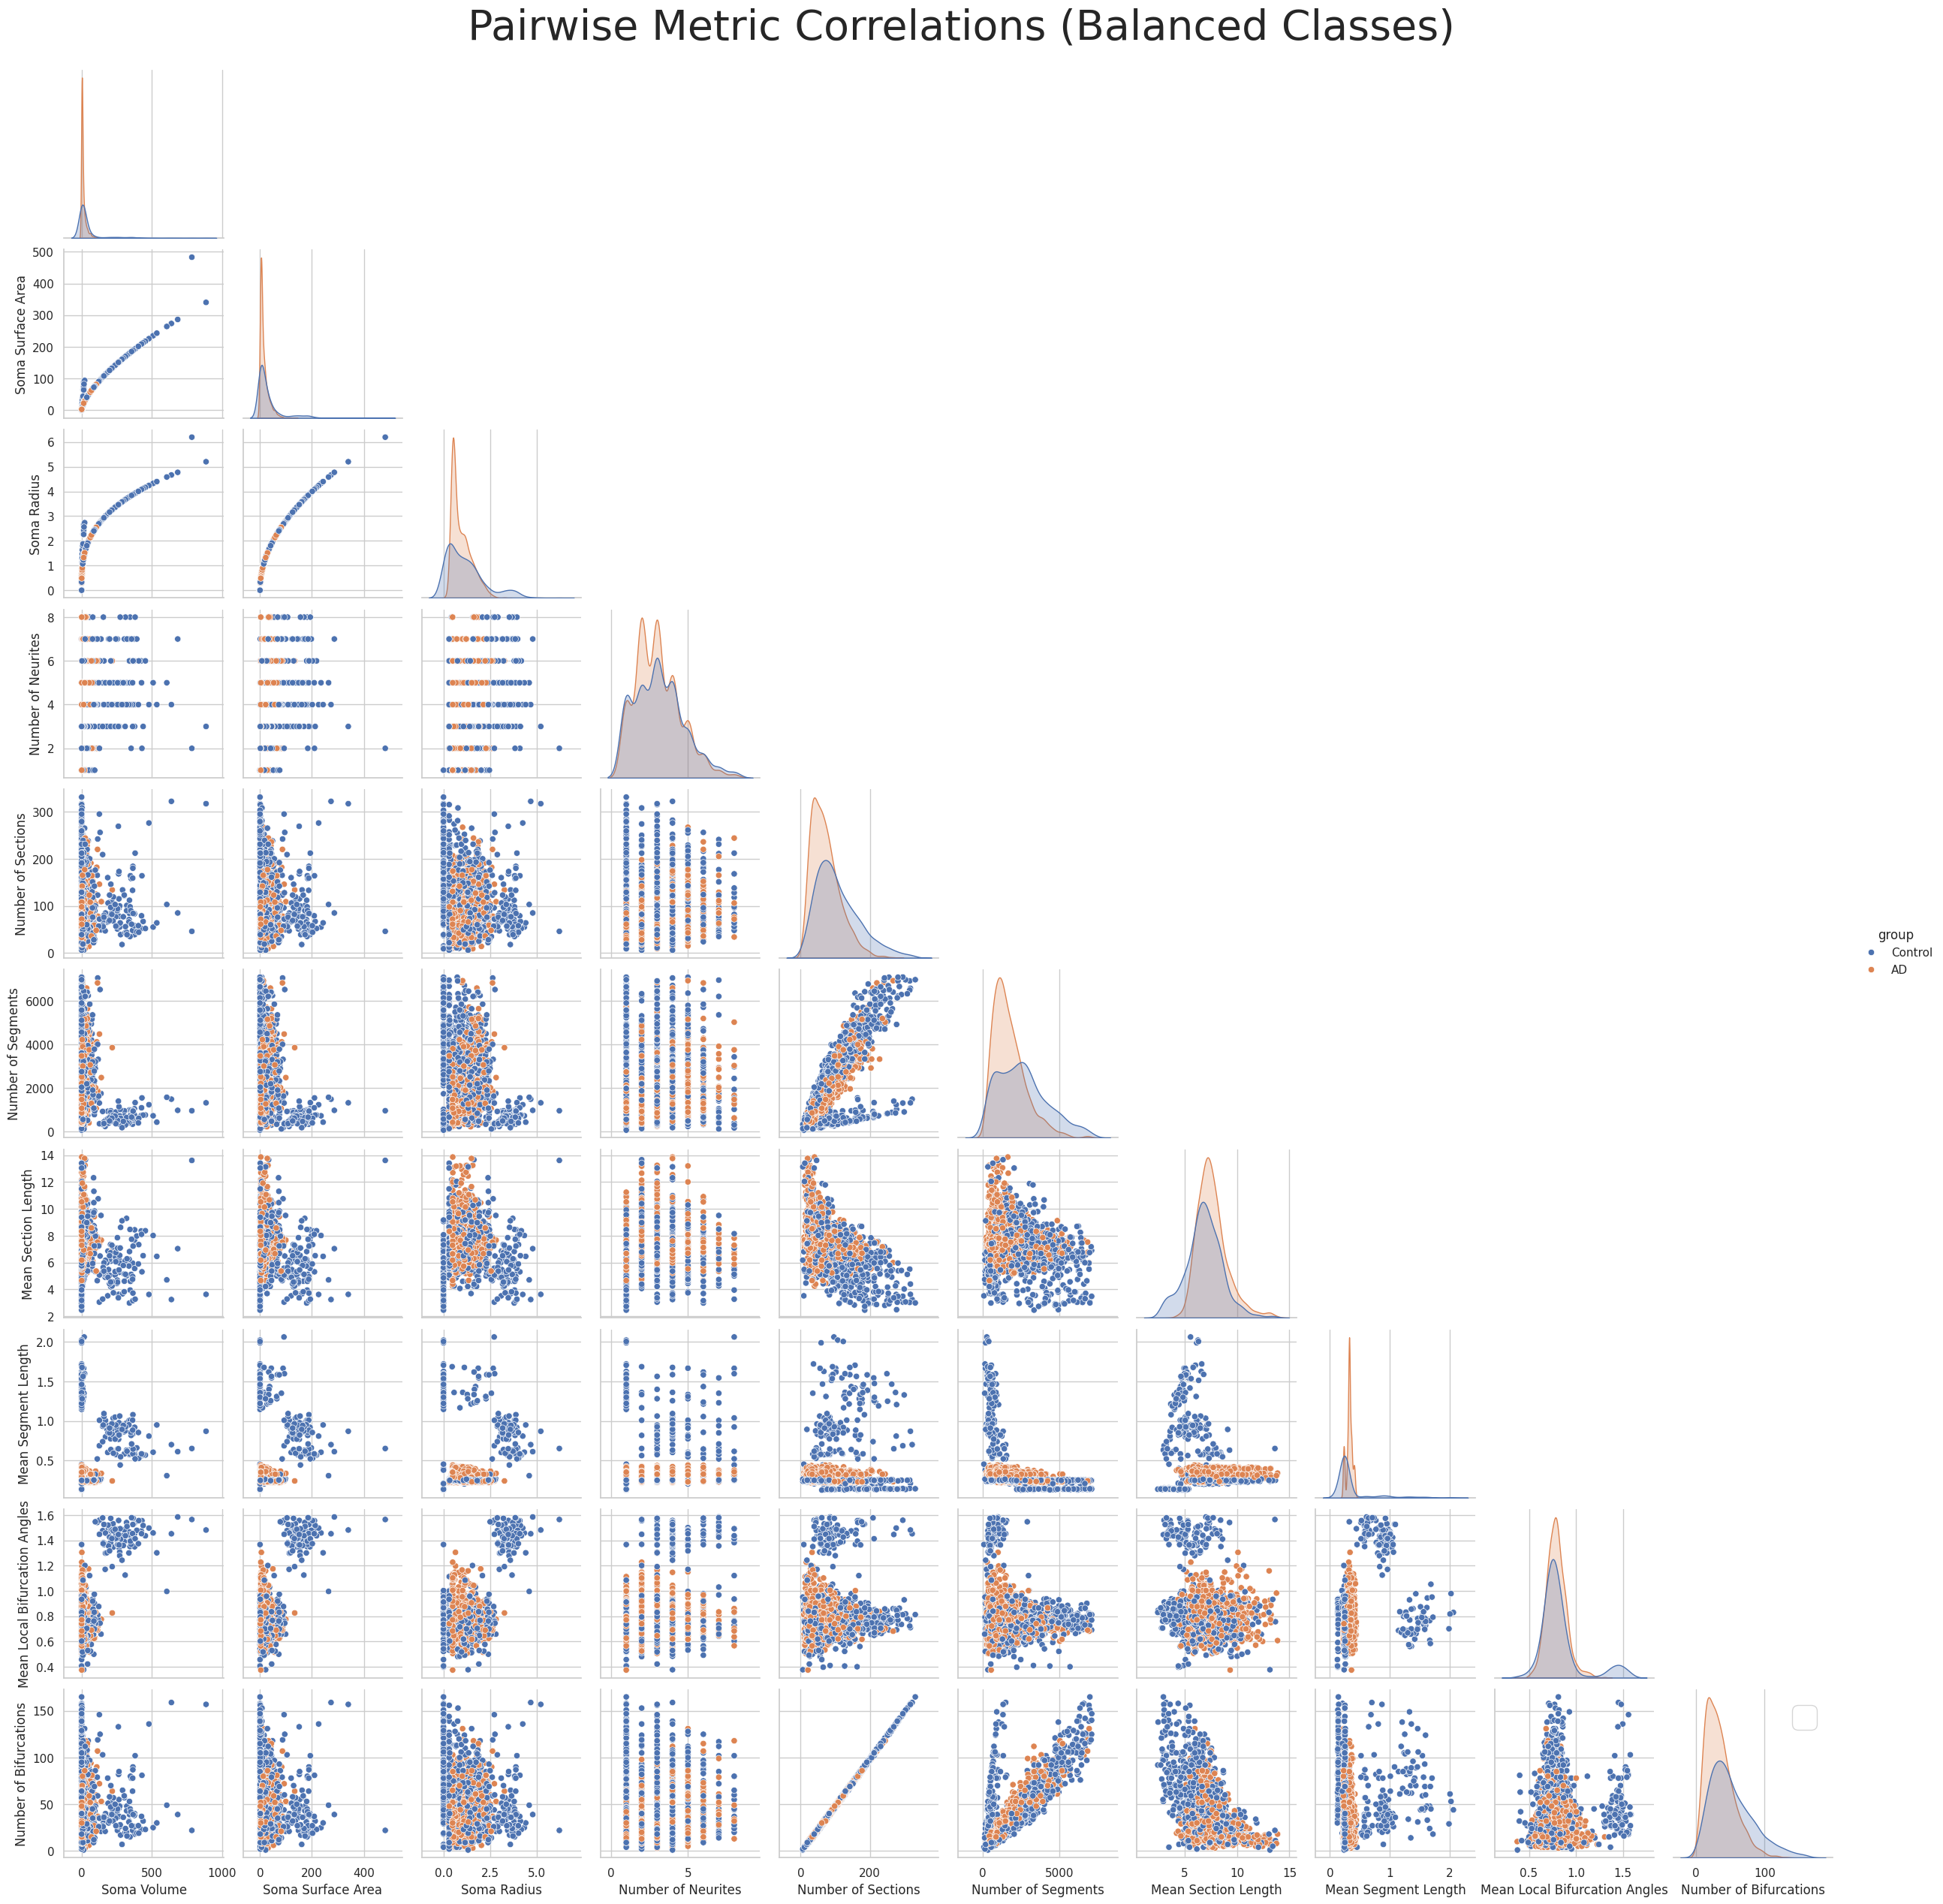

In [45]:
df_plot_balanced = filtered_no_outliers_balanced[metrics + ['group']].copy()

cleaned_metrics_map_balanced = {m: clean_metric_name(m) for m in metrics}
df_plot_balanced = df_plot_balanced.rename(columns=cleaned_metrics_map_balanced)

cleaned_metrics_balanced = [clean_metric_name(m) for m in metrics]

sns.pairplot(df_plot_balanced[cleaned_metrics_balanced + ['group']], hue='group', diag_kind='kde', corner=True)
plt.suptitle('Pairwise Metric Correlations (Balanced Classes)', y=1.02, fontsize = 40)
plt.legend(fontsize=30, title_fontsize=35)
plt.show()

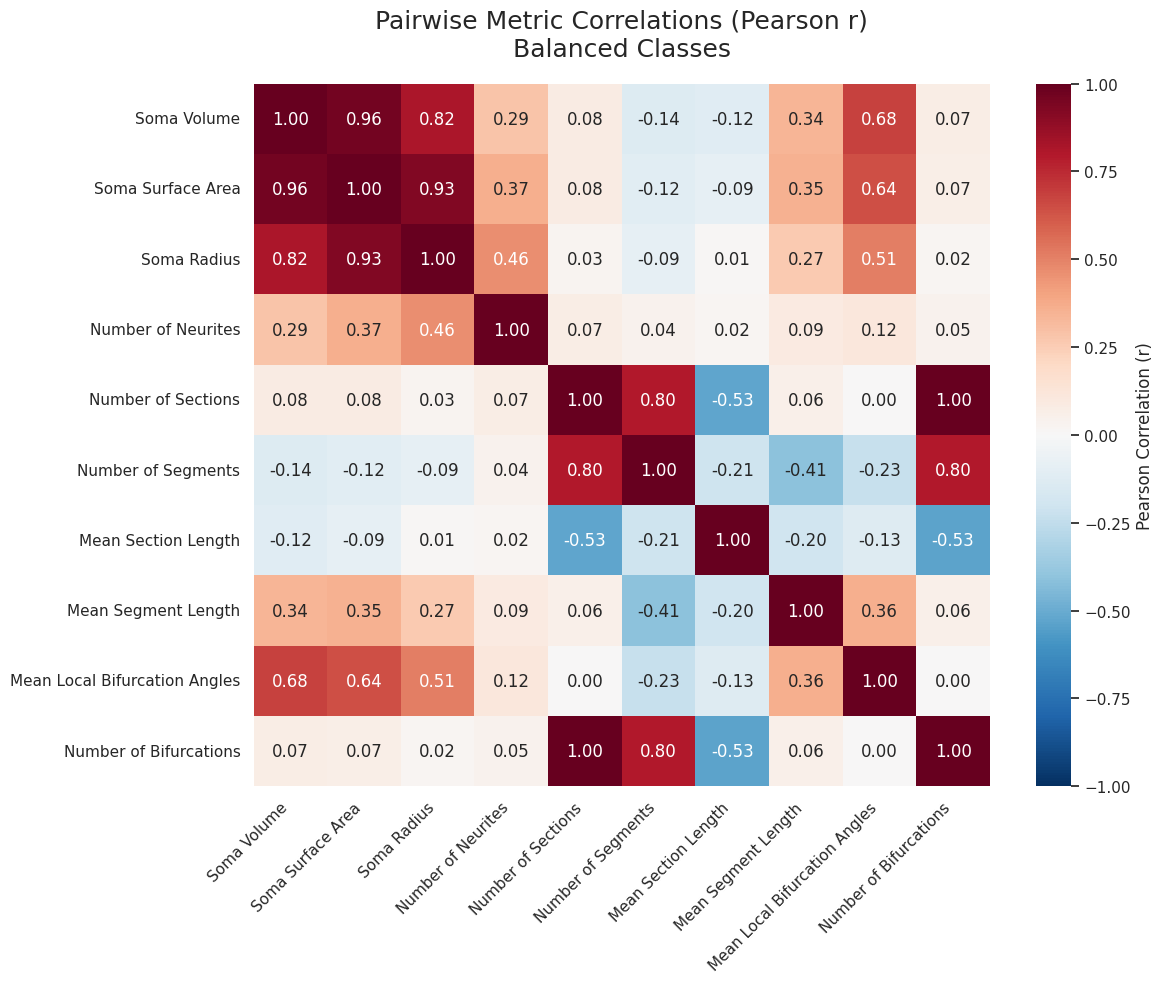

In [46]:
corr_matrix = filtered_no_outliers_balanced[metrics].corr()

corr_matrix.index = [clean_metric_name(m) for m in corr_matrix.index]
corr_matrix.columns = [clean_metric_name(m) for m in corr_matrix.columns]

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Pearson Correlation (r)'}
)

plt.title('Pairwise Metric Correlations (Pearson r)\nBalanced Classes', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

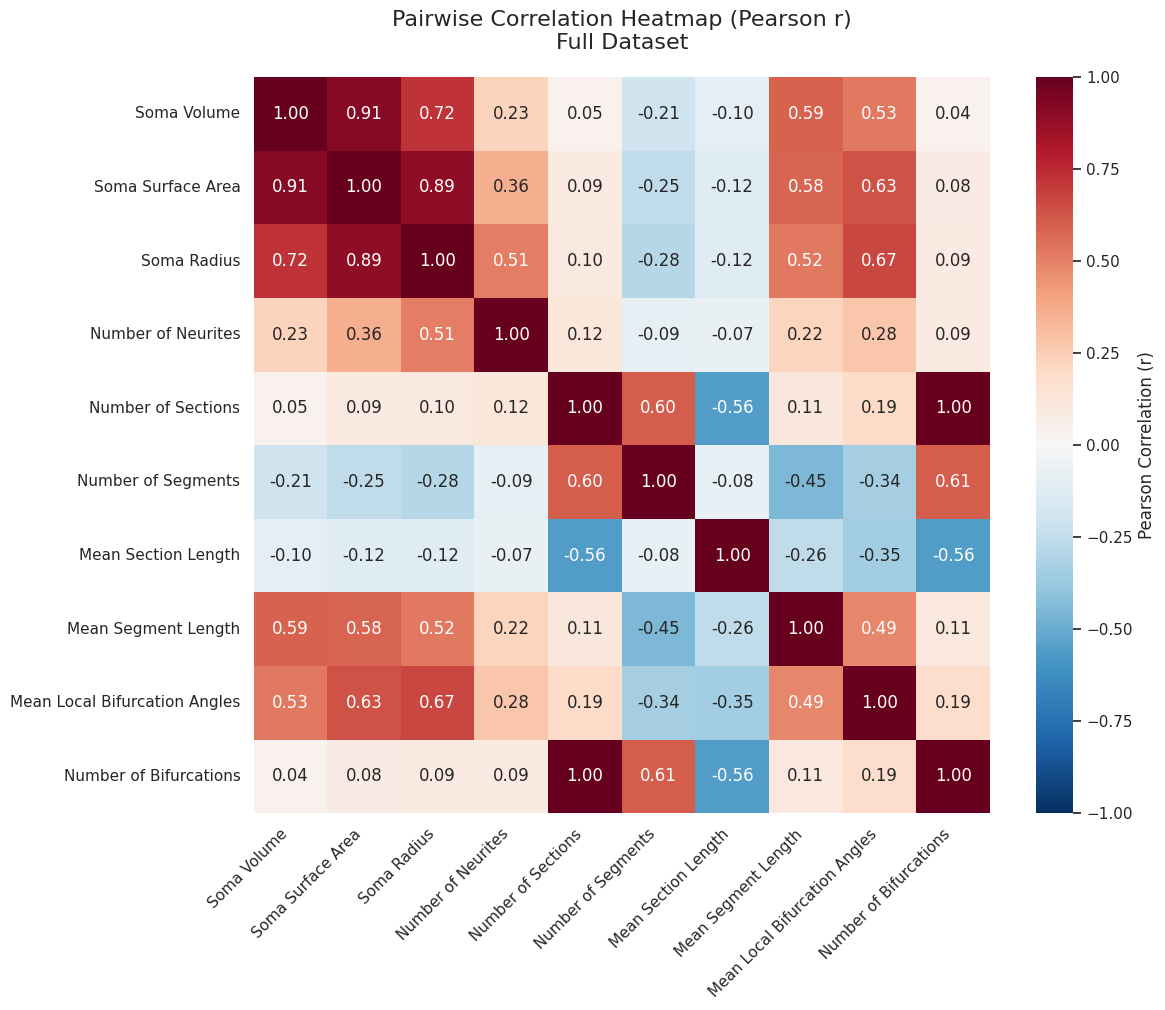

In [49]:
corr_matrix_full = adult_df_no_outliers[metrics].corr()

corr_matrix_full_clean = corr_matrix_full.copy()
corr_matrix_full_clean.index = corr_matrix_full_clean.index.map(clean_metric_name)
corr_matrix_full_clean.columns = corr_matrix_full_clean.columns.map(clean_metric_name)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix_full_clean.astype(float),
    annot=True,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True,
    cbar_kws={'label': 'Pearson Correlation (r)'}
)

plt.title('Pairwise Correlation Heatmap (Pearson r)\nFull Dataset', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [50]:
!pip install shap

import shap
import matplotlib.pyplot as plt


In [51]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_log = cross_val_predict(logreg, X_scaled, y, cv=cv)
acc_scores = cross_val_score(logreg, X_scaled, y, cv=cv, scoring='accuracy')
print(f'Logistic Regression 5-fold CV Accuracy: {np.mean(acc_scores):.3f} ± {np.std(acc_scores):.3f}')

Logistic Regression 5-fold CV Accuracy: 0.715 ± 0.028


In [52]:
print("Classification Report:")
print(classification_report(y, y_pred_log, target_names=['Control', '5xFAD']))

print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_log))

Classification Report:
              precision    recall  f1-score   support

     Control       0.75      0.65      0.70      1176
       5xFAD       0.69      0.78      0.73      1176

    accuracy                           0.71      2352
   macro avg       0.72      0.71      0.71      2352
weighted avg       0.72      0.71      0.71      2352

Confusion Matrix:
[[765 411]
 [260 916]]


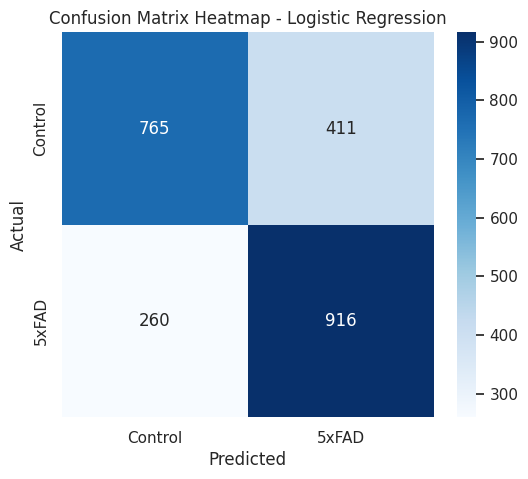

In [53]:
conf_matrix = confusion_matrix(y, y_pred_log)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Control', '5xFAD'], yticklabels=['Control', '5xFAD'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap - Logistic Regression')

plt.show()

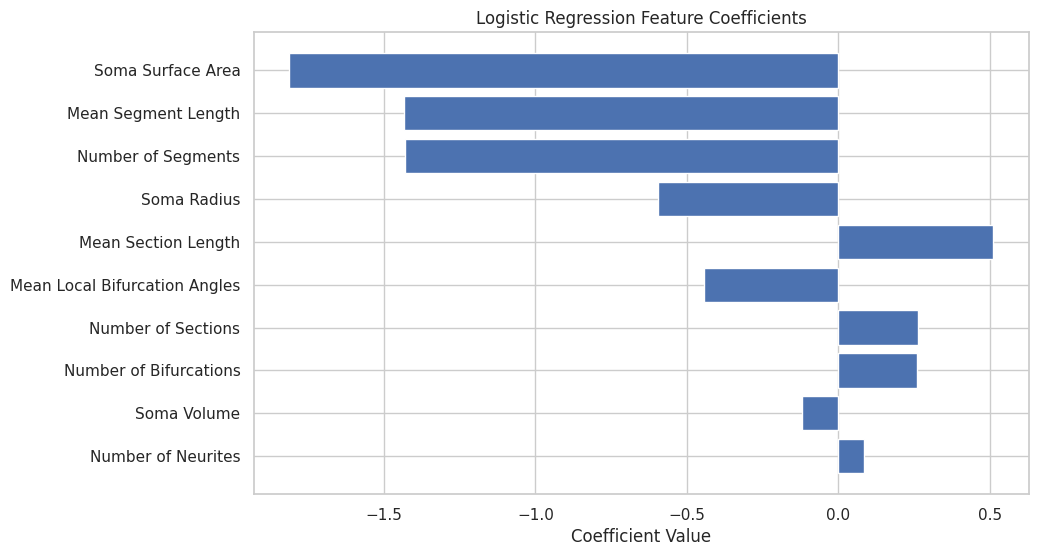

In [65]:
logreg.fit(X_scaled, y)
coef = logreg.coef_[0]
features_names = X.columns
sorted_idx = np.argsort(np.abs(coef))[::-1]

cleaned_feature_names = [clean_metric_name(name) for name in features_names[sorted_idx]]

plt.figure(figsize=(10,6))
plt.barh(cleaned_feature_names, coef[sorted_idx])
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Feature Coefficients')
plt.gca().invert_yaxis()
plt.show()

In [58]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict

def plot_roc_curve(clf, X, y, cv, title):
    y_probas = cross_val_predict(clf, X, y, cv=cv, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y, y_probas)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Chance level')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right', fontsize=10, title_fontsize=15)
    plt.show()

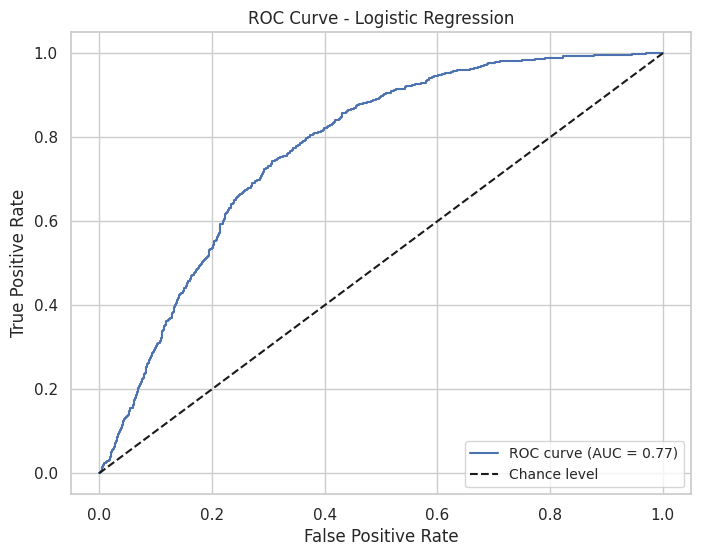

In [59]:
plot_roc_curve(logreg, X_scaled, y, cv, 'ROC Curve - Logistic Regression')

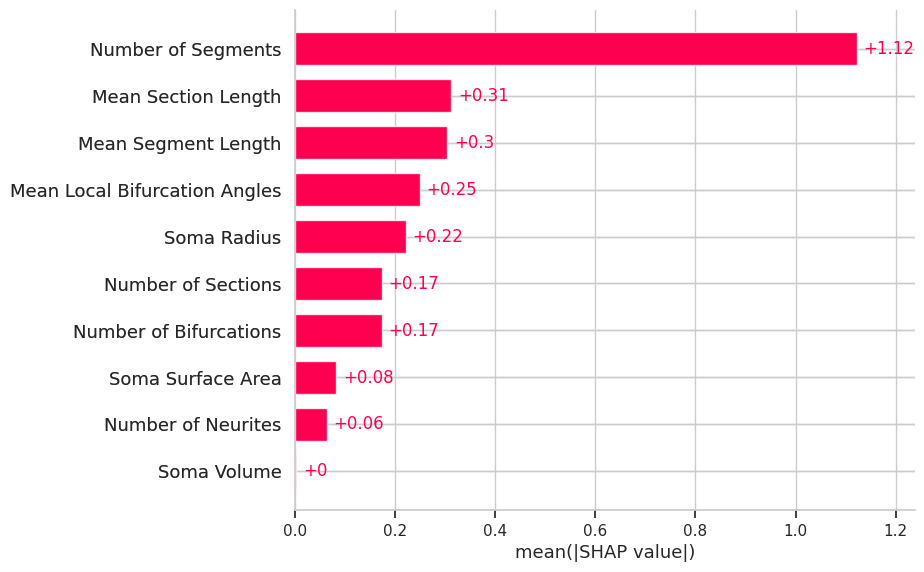

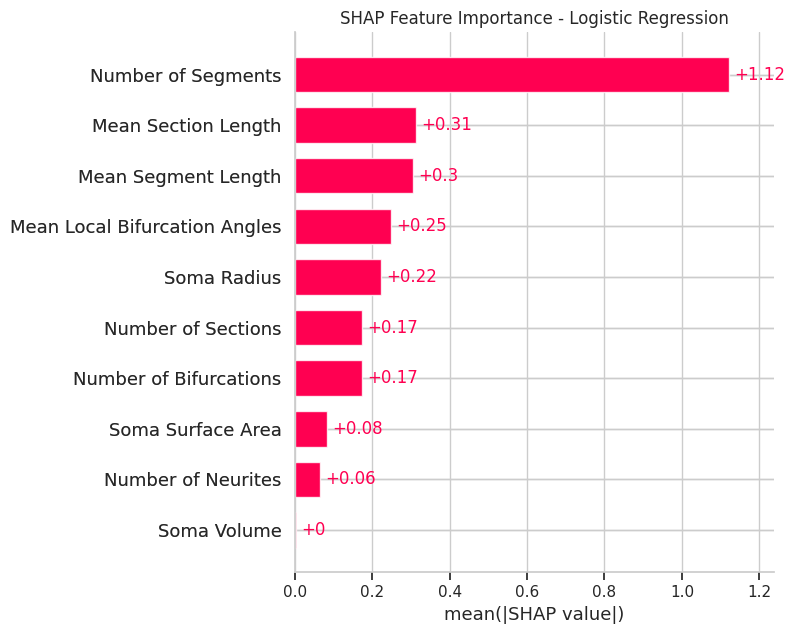

In [90]:
import shap

X_display = pd.DataFrame(X_scaled, columns=metrics)

explainer = shap.LinearExplainer(logreg, X_display)
shap_values = explainer.shap_values(X_display)

cleaned_metrics = [clean_metric_name(m) for m in metrics]
expl = shap.Explanation(values=shap_values, data=X_display, feature_names=cleaned_metrics)
shap.plots.bar(expl)

ax = shap.plots.bar(expl, show=False)

ax.set_title("SHAP Feature Importance - Logistic Regression")

fig = ax.figure

fig.tight_layout()
fig.savefig("shap_summary_logreg_bar.png", dpi=300)
plt.show(fig)
plt.close(fig)

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
import matplotlib.pyplot as plt
import numpy as np

rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_rand = cross_val_predict(rf, X_scaled, y, cv=cv)

acc_scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
print(f'Random Forest 5-fold CV Accuracy: {np.mean(acc_scores):.3f} ± {np.std(acc_scores):.3f}')

Random Forest 5-fold CV Accuracy: 0.959 ± 0.014


In [68]:
print("Classification Report:")
print(classification_report(y, y_pred_rand, target_names=['Control', '5xFAD']))

print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_rand))

Classification Report:
              precision    recall  f1-score   support

     Control       0.94      0.98      0.96      1176
       5xFAD       0.98      0.94      0.96      1176

    accuracy                           0.96      2352
   macro avg       0.96      0.96      0.96      2352
weighted avg       0.96      0.96      0.96      2352

Confusion Matrix:
[[1151   25]
 [  72 1104]]


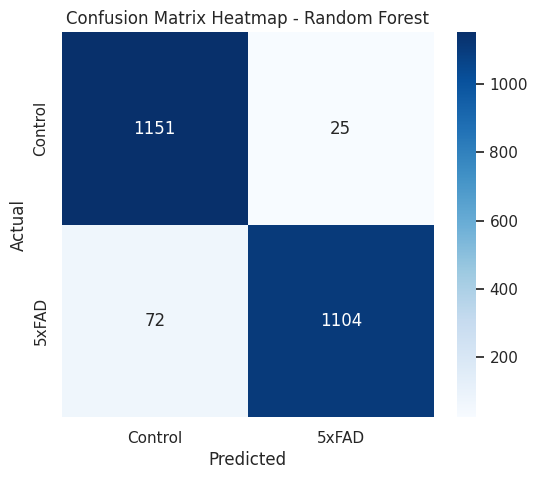

In [69]:
conf_matrix = confusion_matrix(y, y_pred_rand)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Control', '5xFAD'], yticklabels=['Control', '5xFAD'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap - Random Forest')

plt.show()

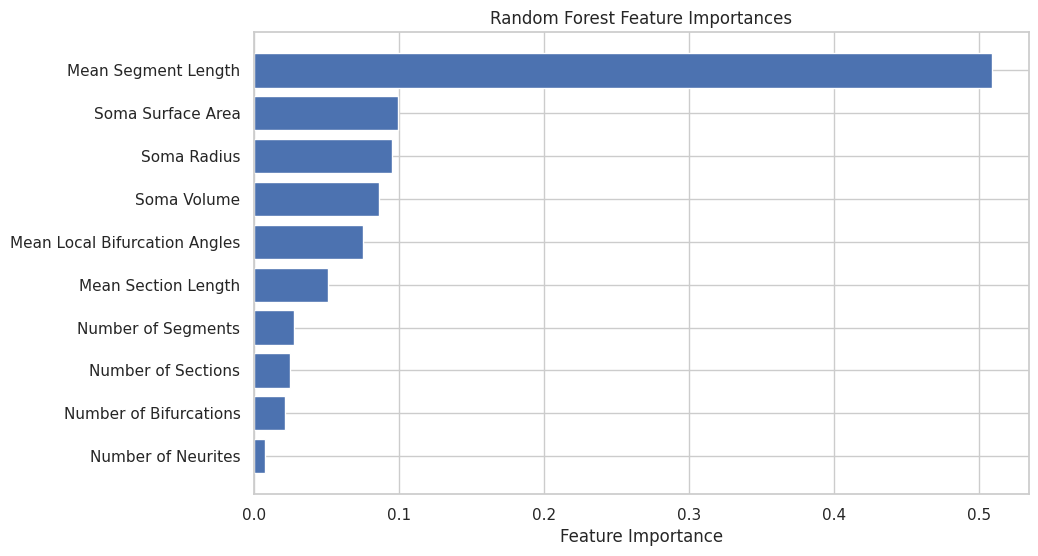

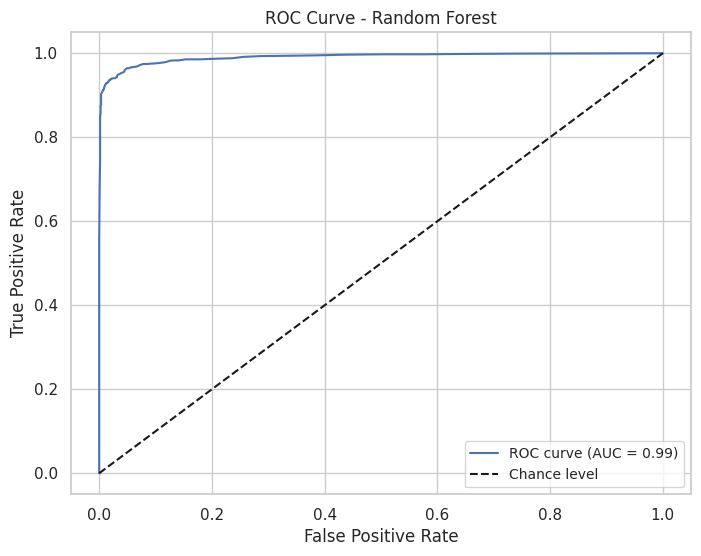

In [75]:
rf.fit(X_scaled, y)

importances = rf.feature_importances_
features_names = X.columns
sorted_idx = np.argsort(importances)[::-1]

cleaned_feature_names = [clean_metric_name(name) for name in features_names[sorted_idx]]

plt.figure(figsize=(10,6))
plt.barh(cleaned_feature_names, importances[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()
plt.show()

plot_roc_curve(rf, X_scaled, y, cv, 'ROC Curve - Random Forest')

 98%|===================| 4614/4704 [00:46<00:00]       

SHAP values shape: (2352, 10, 2)


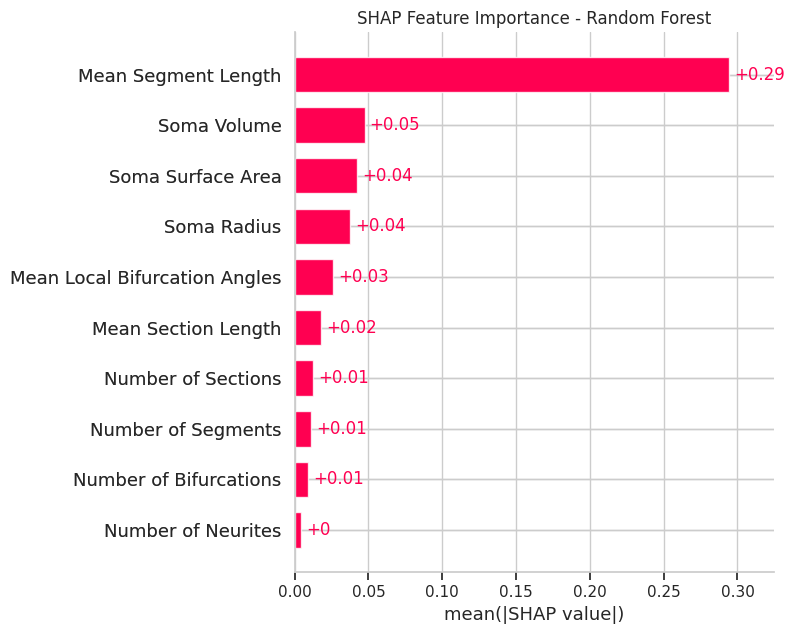

In [80]:
X_shap = X_scaled

explainer = shap.Explainer(rf, X_scaled)

shap_values = explainer(X_scaled, check_additivity = False)

print("SHAP values shape:", shap_values.values.shape)

positive_class_shap = shap_values.values[:, :, 1]

positive_class_exp = shap.Explanation(
    values=positive_class_shap,
    base_values=shap_values.base_values[:, 1],
    data=X_scaled,
    feature_names=cleaned_metrics
)

ax = shap.plots.bar(positive_class_exp, show=False)

ax.set_title("SHAP Feature Importance - Random Forest")

fig = ax.figure

fig.tight_layout()
fig.savefig("shap_summary_rf_bar.png", dpi=300)
plt.show()
plt.close(fig)

In [81]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_gb = cross_val_predict(gb, X_scaled, y, cv=cv)

acc_scores = cross_val_score(gb, X_scaled, y, cv=cv, scoring='accuracy')
print(f'Gradient Boosting 5-fold CV Accuracy: {np.mean(acc_scores):.3f} ± {np.std(acc_scores):.3f}')

Gradient Boosting 5-fold CV Accuracy: 0.954 ± 0.014


In [82]:
print("Classification Report:")
print(classification_report(y, y_pred_gb, target_names=['Control', '5xFAD']))

print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_gb))

Classification Report:
              precision    recall  f1-score   support

     Control       0.94      0.97      0.95      1176
       5xFAD       0.97      0.94      0.95      1176

    accuracy                           0.95      2352
   macro avg       0.95      0.95      0.95      2352
weighted avg       0.95      0.95      0.95      2352

Confusion Matrix:
[[1136   40]
 [  69 1107]]


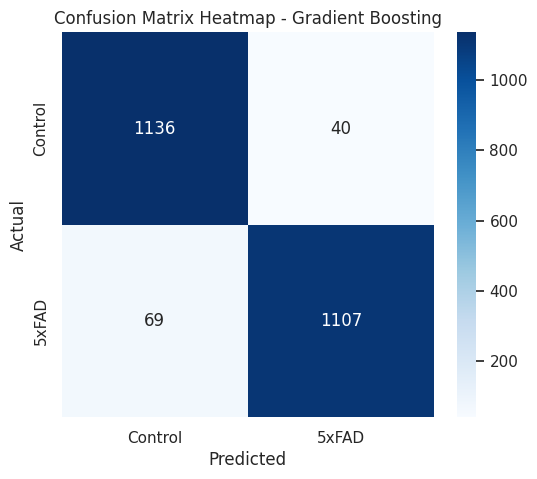

In [83]:
conf_matrix = confusion_matrix(y, y_pred_gb)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Control', '5xFAD'], yticklabels=['Control', '5xFAD'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap - Gradient Boosting')

plt.show()

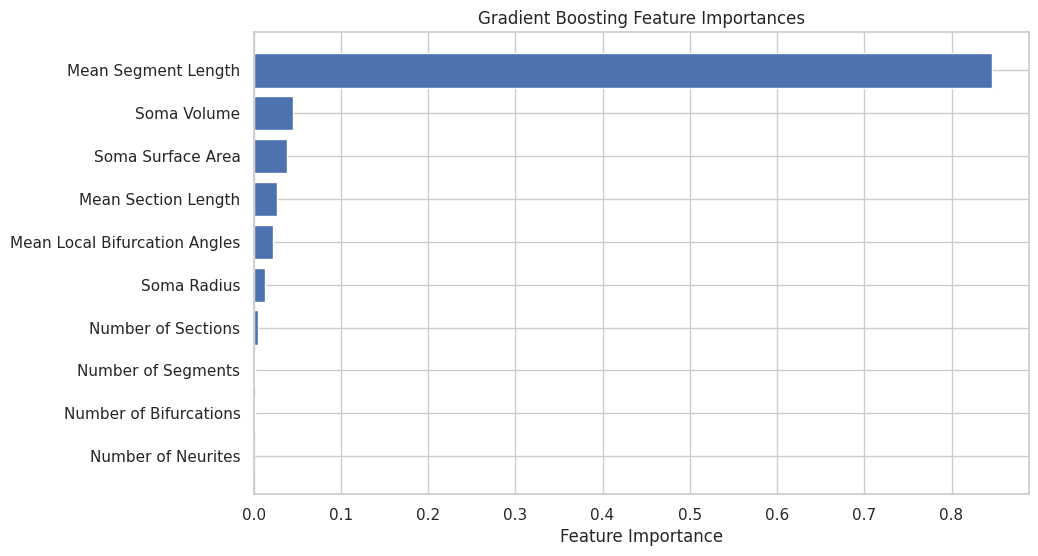

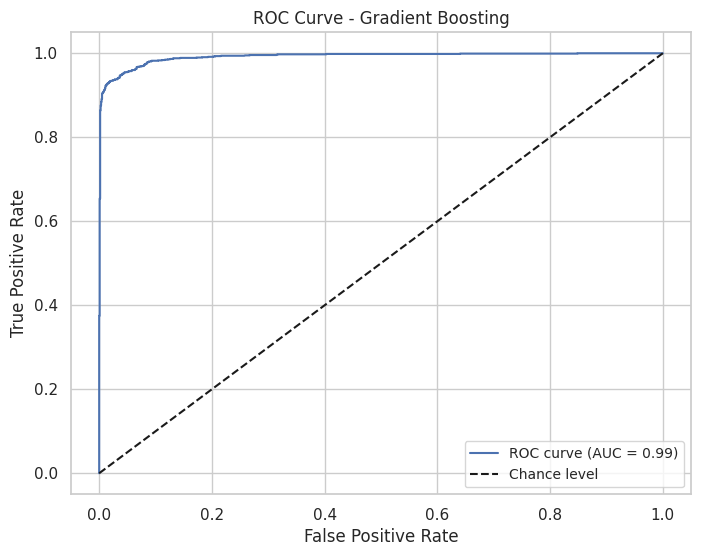

In [85]:
gb.fit(X_scaled, y)

importances = gb.feature_importances_
features_names = X.columns
sorted_idx = np.argsort(importances)[::-1]

cleaned_feature_names = [clean_metric_name(name) for name in features_names[sorted_idx]]

plt.figure(figsize=(10,6))
plt.barh(cleaned_feature_names, importances[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Gradient Boosting Feature Importances')
plt.gca().invert_yaxis()
plt.show()

plot_roc_curve(gb, X_scaled, y, cv, 'ROC Curve - Gradient Boosting')

SHAP values shape: (2352, 10)


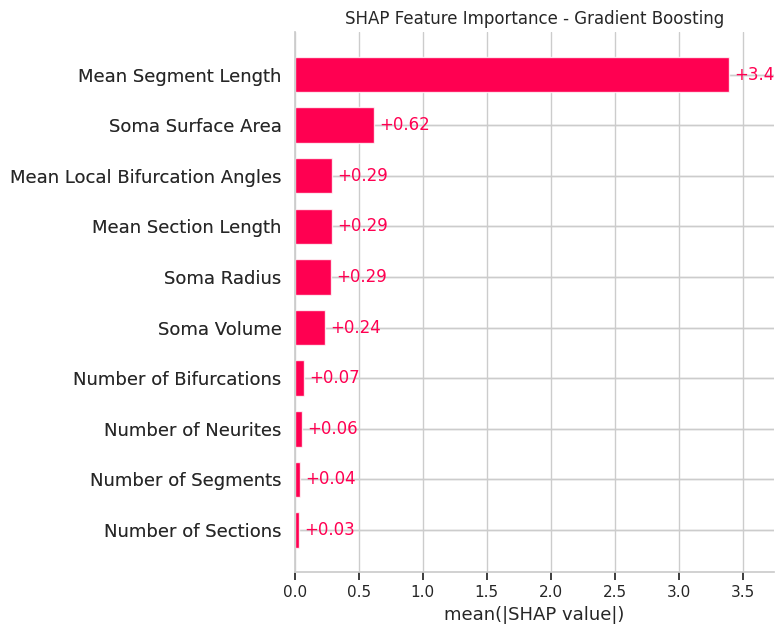

In [88]:
explainer = shap.Explainer(gb, X_scaled)

shap_values = explainer(X_scaled, check_additivity = False)

print("SHAP values shape:", shap_values.values.shape)

positive_class_shap = shap_values.values

positive_class_exp_gb = shap.Explanation(
    values=positive_class_shap,
    base_values=shap_values.base_values,
    data=X_scaled,
    feature_names=cleaned_metrics
)

ax = shap.plots.bar(positive_class_exp_gb, show=False)

ax.set_title("SHAP Feature Importance - Gradient Boosting")

fig = ax.figure

fig.tight_layout()
fig.savefig("shap_summary_gb_bar.png", dpi=300)
plt.show(fig)
plt.close(fig)



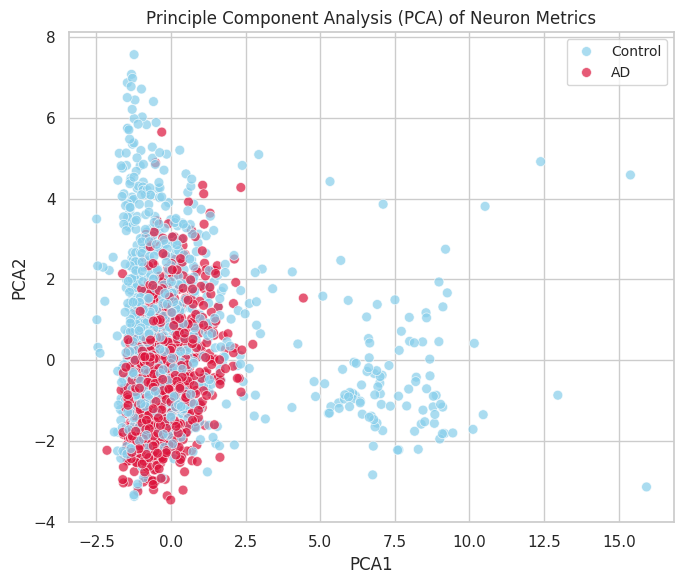

In [92]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

X_no_outliers = filtered_no_outliers_balanced[metrics]
X_no_outliers_scaled = scaler.fit_transform(X_no_outliers)

filtered_no_outliers_balanced = filtered_no_outliers_balanced.copy()
filtered_no_outliers_balanced.loc[:, 'label_str'] = filtered_no_outliers_balanced['label'].map({0: 'Control', 1: 'AD'})

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_no_outliers_scaled)

filtered_no_outliers_balanced.loc[:, 'PCA1'] = pca_result[:, 0]
filtered_no_outliers_balanced.loc[:, 'PCA2'] = pca_result[:, 1]


plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=filtered_no_outliers_balanced,
    x='PCA1', y='PCA2',
    hue='label_str',
    palette={'Control': 'skyblue', 'AD': 'crimson'},
    alpha=0.7,
    s=50
)
plt.title('Principle Component Analysis (PCA) of Neuron Metrics')
plt.legend(fontsize=10, title_fontsize=20)
plt.tight_layout()
plt.show()

In [93]:
feature_names = X.columns

loadings = pd.DataFrame(pca.components_.T,
                        columns=['PCA1', 'PCA2'],
                        index=feature_names)

top_pca1 = loadings['PCA1'].abs().sort_values(ascending=False).head(3)
top_pca2 = loadings['PCA2'].abs().sort_values(ascending=False).head(3)

print("Top 3 features contributing to PCA1:")
print(top_pca1)

print("\nTop 3 features contributing to PCA2:")
print(top_pca2)

Top 3 features contributing to PCA1:
soma_surface_area    0.503631
soma_volume          0.489708
soma_radius          0.464825
Name: PCA1, dtype: float64

Top 3 features contributing to PCA2:
n_bifs                0.562252
number_of_sections    0.562094
number_of_segments    0.496912
Name: PCA2, dtype: float64


In [94]:
top_features = list(set(top_pca1.index) | set(top_pca2.index))
X_kmeans = filtered_no_outliers_balanced[top_features]

In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans)

In [96]:
from sklearn.cluster import KMeans

k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_kmeans_scaled)

filtered_no_outliers_balanced['cluster'] = clusters

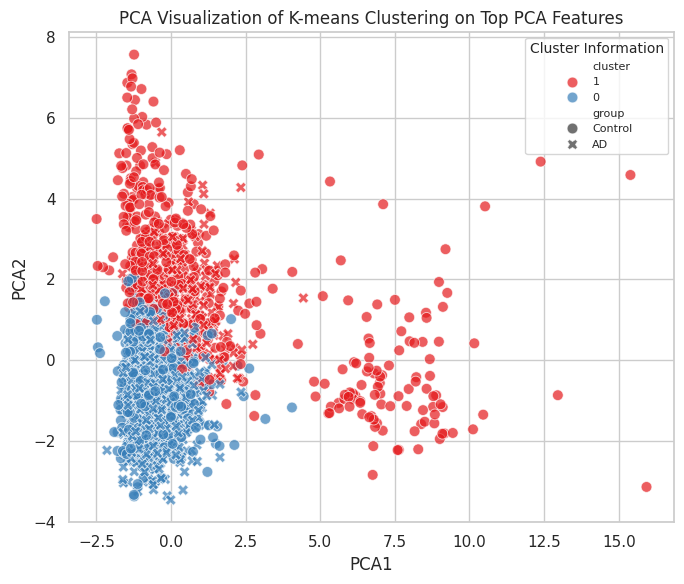

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=pca_result[:, 0], y=pca_result[:, 1],
    hue=filtered_no_outliers_balanced['cluster'].astype(str),
    palette='Set1',
    style=filtered_no_outliers_balanced['group'],
    s=60,
    alpha=0.7
)
plt.title('PCA Visualization of K-means Clustering on Top PCA Features')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Cluster Information', fontsize=8,title_fontsize=10)
plt.tight_layout()
plt.show()

In [98]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_kmeans_scaled, clusters)
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.445


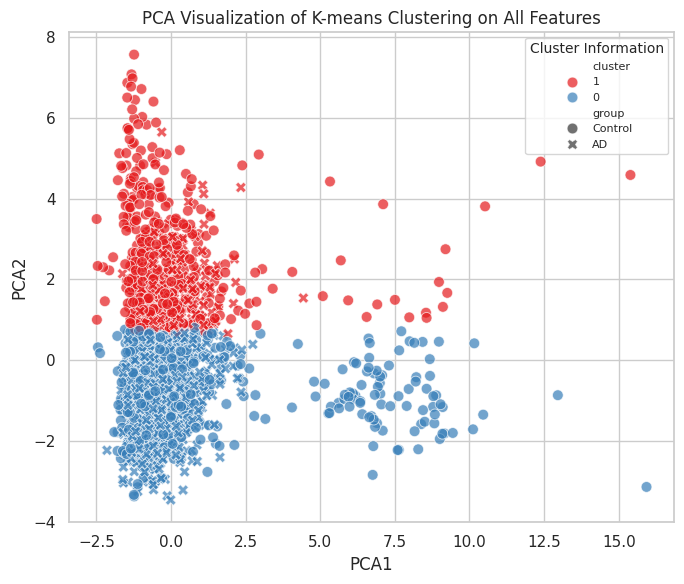

In [99]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_no_outliers_scaled)

filtered_no_outliers_balanced['cluster'] = clusters

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_no_outliers_scaled)

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=pca_result[:, 0], y=pca_result[:, 1],
    hue=filtered_no_outliers_balanced['cluster'].astype(str),
    palette='Set1',
    style=filtered_no_outliers_balanced['group'],
    s=60,
    alpha=0.7
)
plt.title('PCA Visualization of K-means Clustering on All Features')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Cluster Information', fontsize=8,title_fontsize=10)
plt.tight_layout()
plt.show()

In [100]:
score = silhouette_score(X_no_outliers_scaled, clusters)
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.283


In [101]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

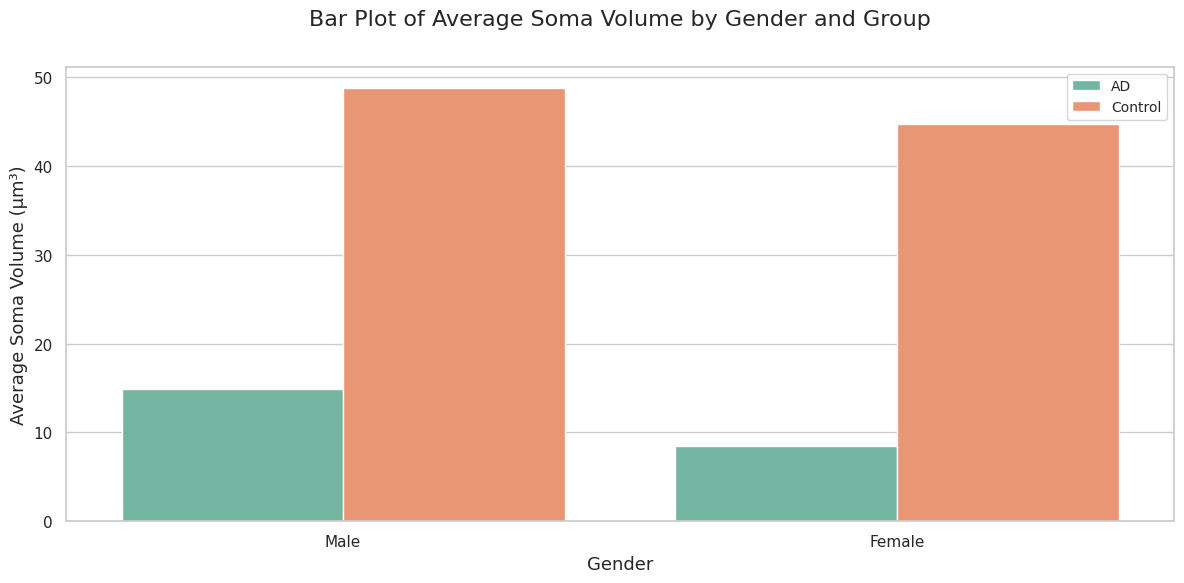

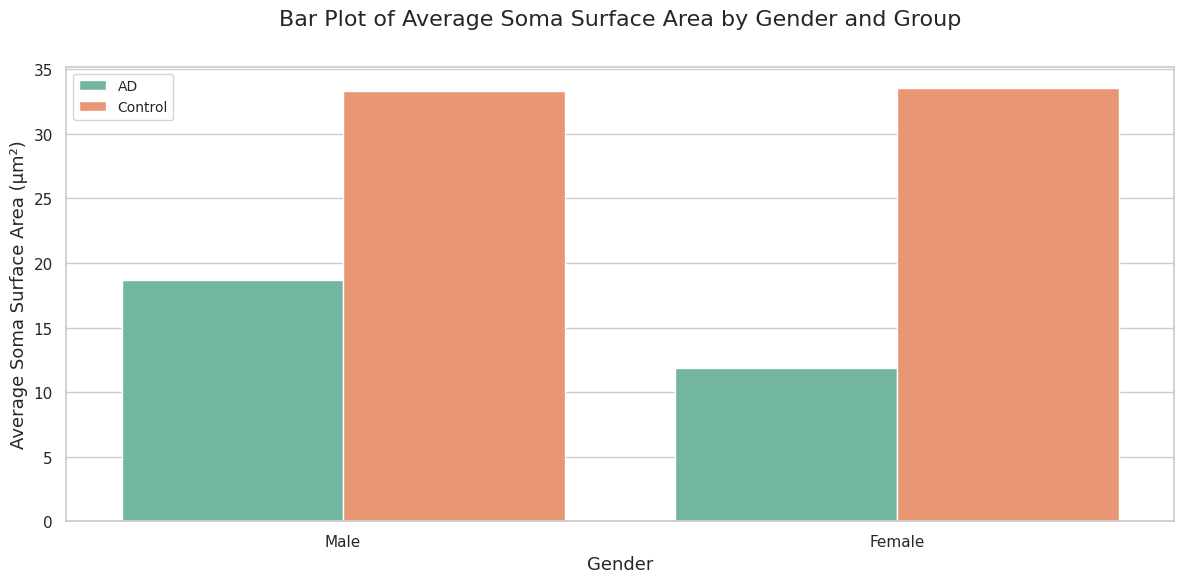

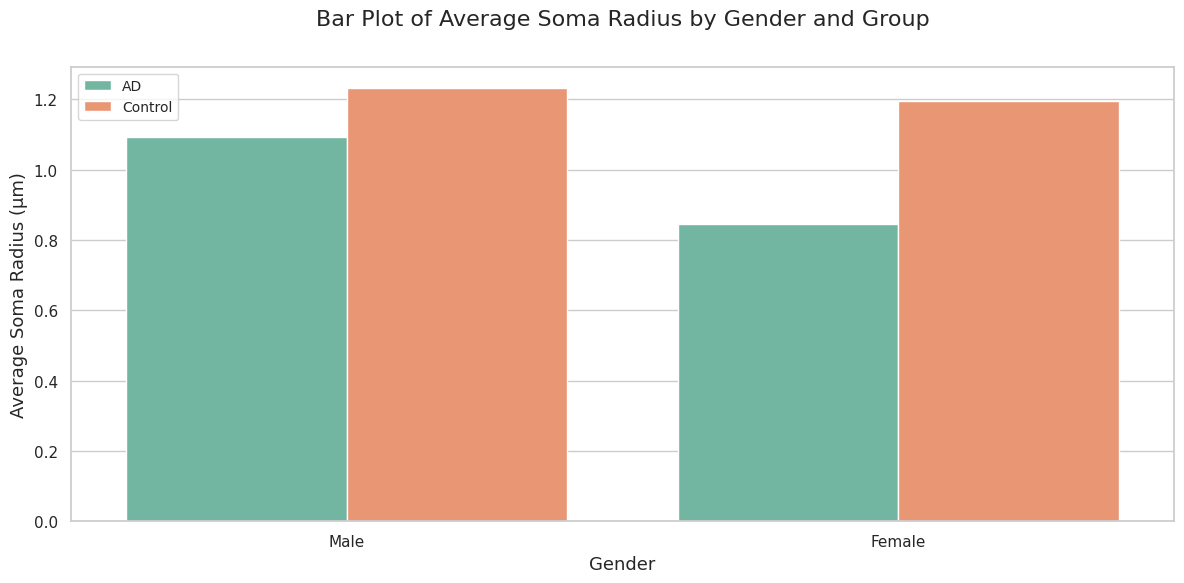

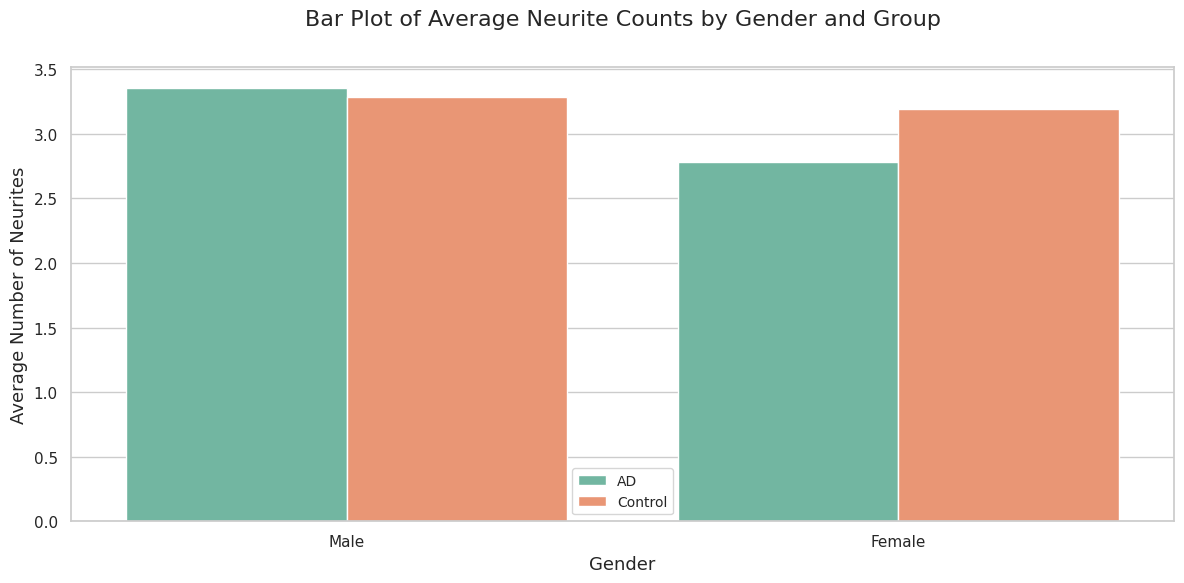

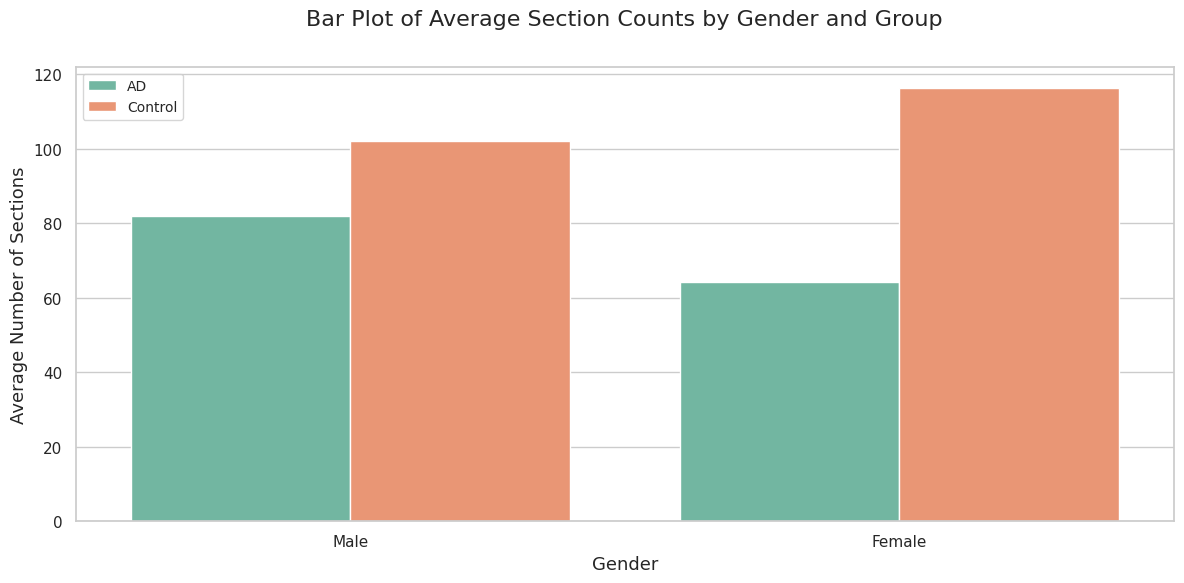

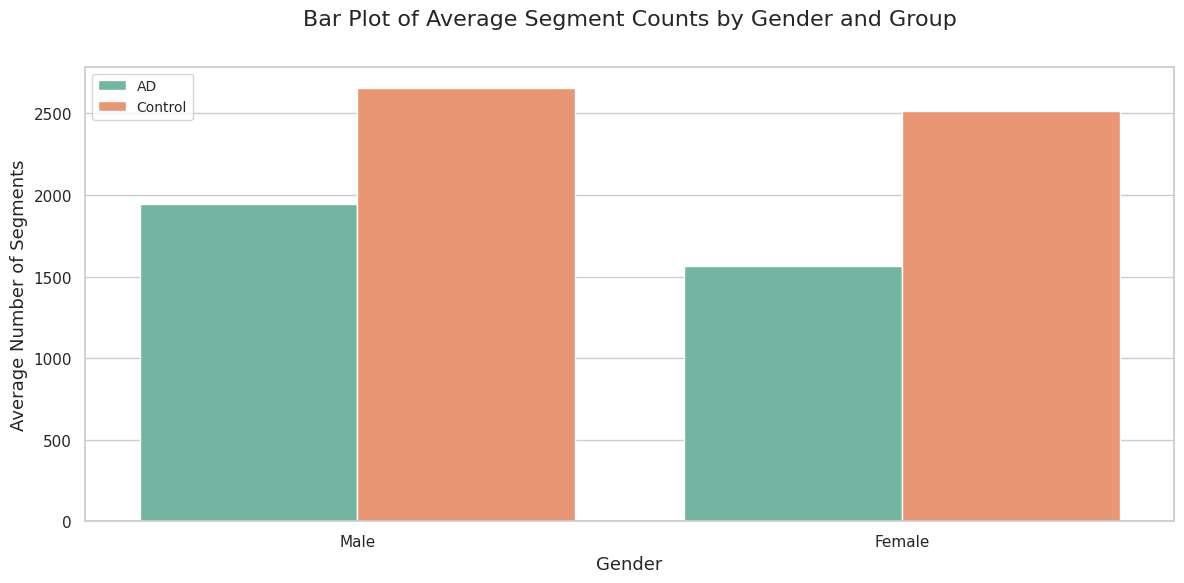

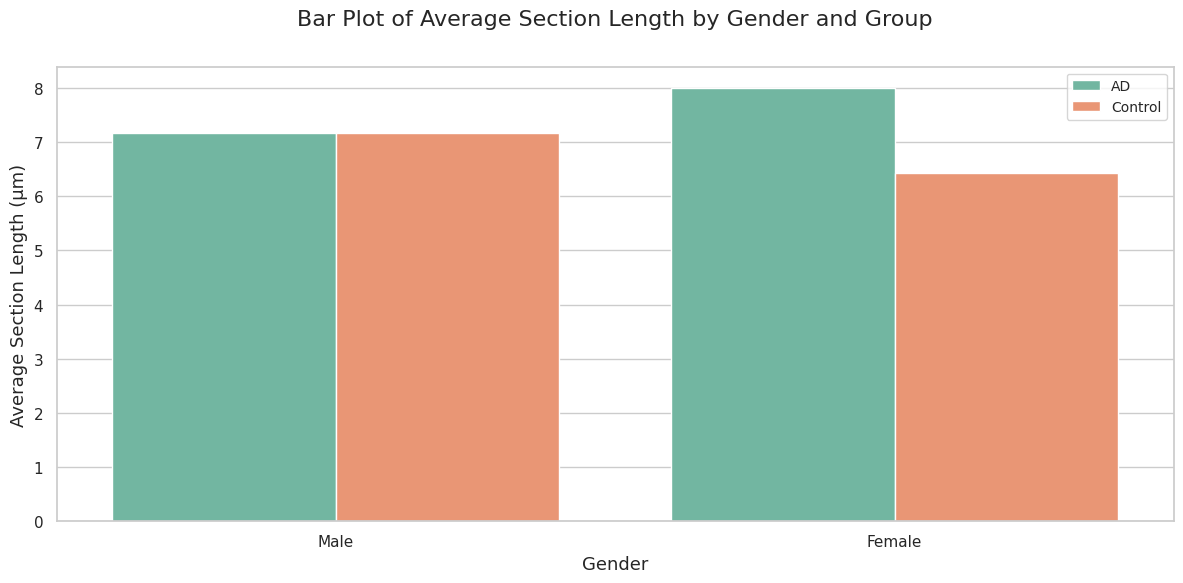

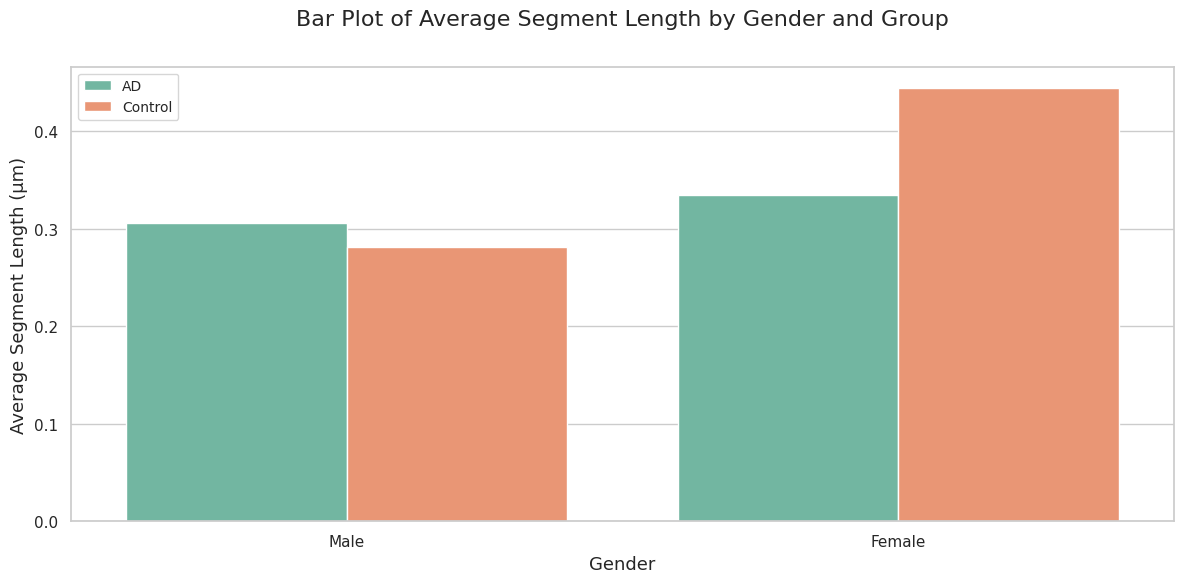

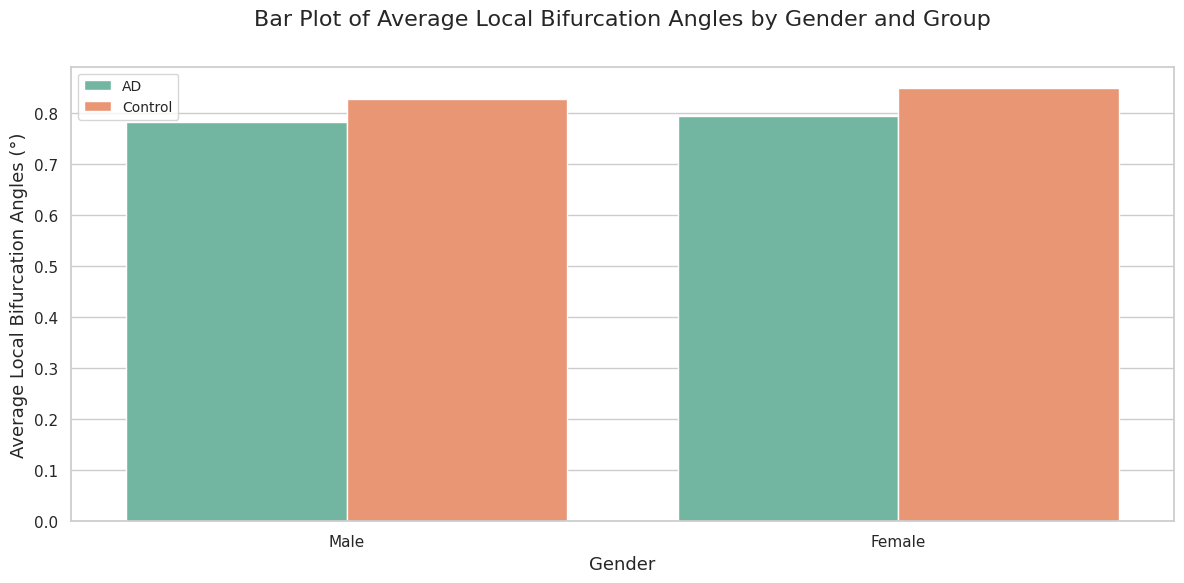

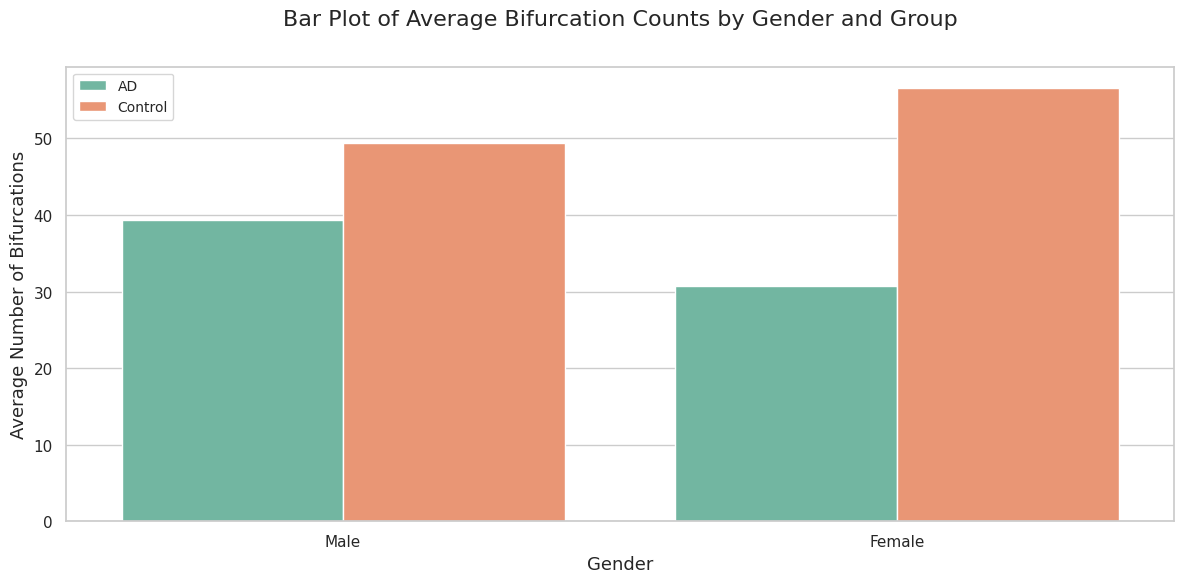

In [104]:
def make_singular(word):
    if word.endswith('s') and len(word) > 1:
        return word[:-1]
    return word

gender_order = ['Male', 'Female']

from scipy.stats import zscore
z_scores = adult_df[metrics].apply(zscore)
adult_df_no_outliers = adult_df[(z_scores.abs() <= 3).all(axis=1)].copy()

for metric in metrics:
    plt.figure(figsize=(12, 6))

    avg_df = adult_df_no_outliers.groupby(['gender', 'group'])[metric].mean().reset_index()

    sns.barplot(data=avg_df, x='gender', y=metric, hue='group', order=gender_order, palette='Set2')

    unit = metric_units.get(metric, 'Unit')

    if 'number_of_' in metric:
        metric_name = metric.replace("number_of_", "").replace("_", " ").title()
        singular_metric_name = make_singular(metric_name.split(" ")[-1])
        title = f'Bar Plot of Average {singular_metric_name} Counts by Gender and Group'
        y_label = f'Average Number of {metric_name}'

    elif metric == 'n_bifs':
        title = f'Bar Plot of Average Bifurcation Counts by Gender and Group'
        y_label = f'Average Number of Bifurcations'

    elif metric in ['mean_segment_length', 'mean_section_length']:
        metric_clean = metric.replace("mean_", "").replace("_", " ").title()
        title = f'Bar Plot of Average {metric_clean} by Gender and Group'
        y_label = f'Average {metric_clean}'
        if unit:
            y_label += f' ({unit})'
    elif metric == 'mean_local_bif_angle':
        title = f'Bar Plot of Average Local Bifurcation Angles by Gender and Group'
        y_label = f'Average Local Bifurcation Angles ({unit})'
    else:
        title = f'Bar Plot of Average {metric.replace("_", " ").title()} by Gender and Group'
        if unit is None:
            y_label = f'Average {metric.replace("_", " ").title()}'
        else:
            y_label = f'Average {metric.replace("_", " ").title()} ({unit})'

    plt.title(title, fontsize=16, pad=30)
    plt.xlabel('Gender', fontsize=13)
    plt.ylabel(y_label, fontsize=13)
    plt.legend(fontsize=10, title_fontsize=12)
    plt.tight_layout()

    plt.show()

In [105]:
results_gender = []

for gender in ['Male', 'Female']:
    gender_df = adult_df_no_outliers[adult_df_no_outliers['gender'] == gender]

    for metric in metrics:
        vals_ad = gender_df[gender_df['group'] == 'AD'][metric].dropna()
        vals_control = gender_df[gender_df['group'] == 'Control'][metric].dropna()

        if len(vals_ad) >= 2 and len(vals_control) >= 2:
            t_stat, p_val = ttest_ind(vals_ad, vals_control, equal_var=False)
            results_gender.append({
                'gender': gender,
                'metric': metric,
                't_stat': t_stat,
                'p_val': p_val,
                'n_ad': len(vals_ad),
                'mean_ad': vals_ad.mean(),
                'std_ad': vals_ad.std(),
                'median_ad': vals_ad.median(),
                'n_control': len(vals_control),
                'mean_control': vals_control.mean(),
                'std_control': vals_control.std(),
                'median_control': vals_control.median()
            })

results_gender_df = pd.DataFrame(results_gender)
results_gender_df = results_gender_df.sort_values('p_val')
print(results_gender_df.head(20))

    gender                metric     t_stat         p_val  n_ad      mean_ad  \
14  Female    number_of_sections -22.029258  4.124191e-96   653    64.173047   
19  Female                n_bifs -21.895433  4.000157e-95   653    30.693721   
16  Female   mean_section_length  20.959901  4.441423e-86   653     7.991201   
15  Female    number_of_segments -15.186665  3.185681e-49   653  1562.359877   
11  Female     soma_surface_area -13.792710  3.888086e-41   653    11.827052   
10  Female           soma_volume -12.955780  1.725956e-36   653     8.463599   
5     Male    number_of_segments -10.520079  5.565531e-25   516  1943.893411   
12  Female           soma_radius  -9.883524  1.618066e-22   653     0.845995   
17  Female   mean_segment_length  -9.391458  2.283415e-20   653     0.334444   
0     Male           soma_volume  -8.981212  1.028292e-18   516    14.846584   
1     Male     soma_surface_area  -7.753265  1.698136e-14   516    18.699284   
9     Male                n_bifs  -7.269

In [106]:
results_gender_df['p_val_raw'] = results_gender_df['p_val']
results_gender_df['p_val'] = (results_gender_df['p_val'] * 20).clip(upper=1.0)

In [107]:
results_gender_df['metric_clean'] = results_gender_df['metric'].apply(clean_metric_name)

In [108]:
results_gender_df.to_csv('gender_ttest_results.csv', index=False)

In [109]:
results_gender_df.head(5)

,gender,metric,t_stat,p_val,n_ad,mean_ad,std_ad,median_ad,n_control,mean_control,std_control,median_control,p_val_raw,metric_clean
14,Female,number_of_sections,-22.029258,8.248382e-95,653,64.173047,39.020591,56.000000,1349,116.285397,66.359583,101.000000,4.124191e-96,Number of Sections
19,Female,n_bifs,-21.895433,8.000314e-94,653,30.693721,19.362095,26.000000,1349,56.546331,33.259683,49.000000,4.000157e-95,Number of Bifurcations
16,Female,mean_section_length,20.959901,8.882846e-85,653,7.991201,1.456646,7.726576,1349,6.420634,1.786340,6.486686,4.441423e-86,Mean Section Length
15,Female,number_of_segments,-15.186665,6.371363e-48,653,1562.359877,1069.574724,1300.000000,1349,2516.073388,1719.542823,2347.000000,3.185681e-49,Number of Segments
11,Female,soma_surface_area,-13.792710,7.776172e-40,653,11.827052,15.090774,5.049386,1349,33.520032,53.539727,10.559146,3.888086e-41,Soma Surface Area


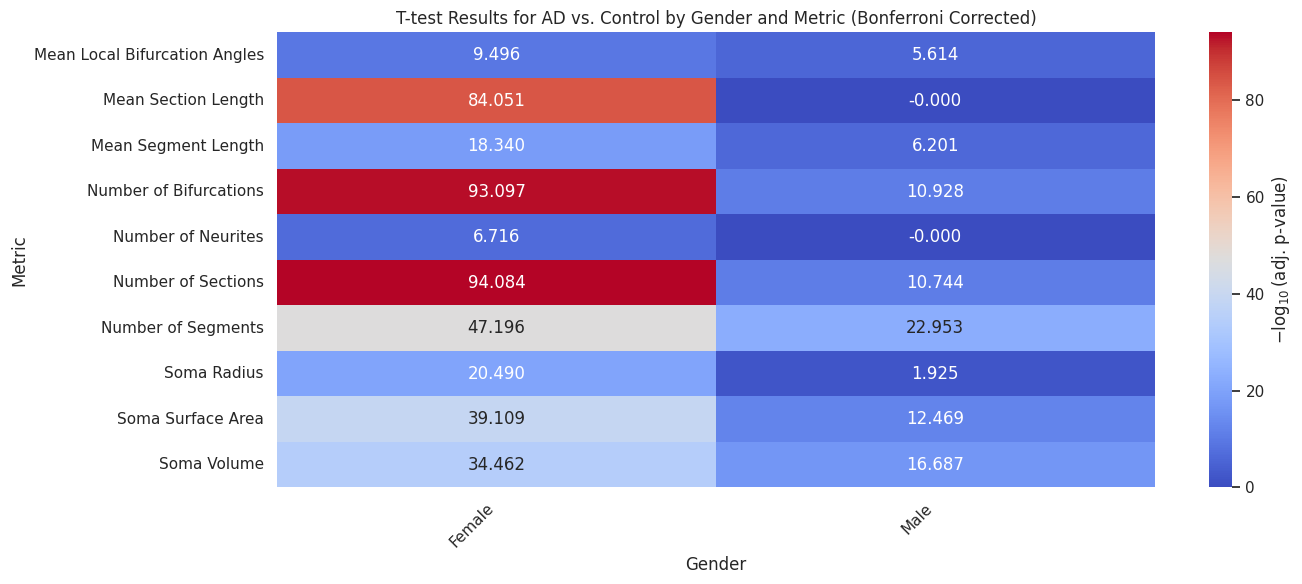

In [115]:
# 1. Recalculate Bonferroni corrected p-values from p_val_raw for robustness
correction_factor = 20 # Assuming 20 tests for Bonferroni correction
results_gender_df['p_val_corrected'] = (results_gender_df['p_val_raw'] * correction_factor).clip(upper=1.0)
pval_matrix = results_gender_df.pivot(index='metric_clean', columns='gender', values='p_val_corrected')
log_pvals = -np.log10(pval_matrix.replace(0, 1e-300))

# 2. Plotting
plt.figure(figsize=(14, 6))

sns.heatmap(
    log_pvals,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    cbar_kws={'label': r'$-\log_{10}(\text{adj. p-value})$'}
)

plt.title("T-test Results for AD vs. Control by Gender and Metric (Bonferroni Corrected)")
plt.xlabel("Gender")
plt.ylabel("Metric")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

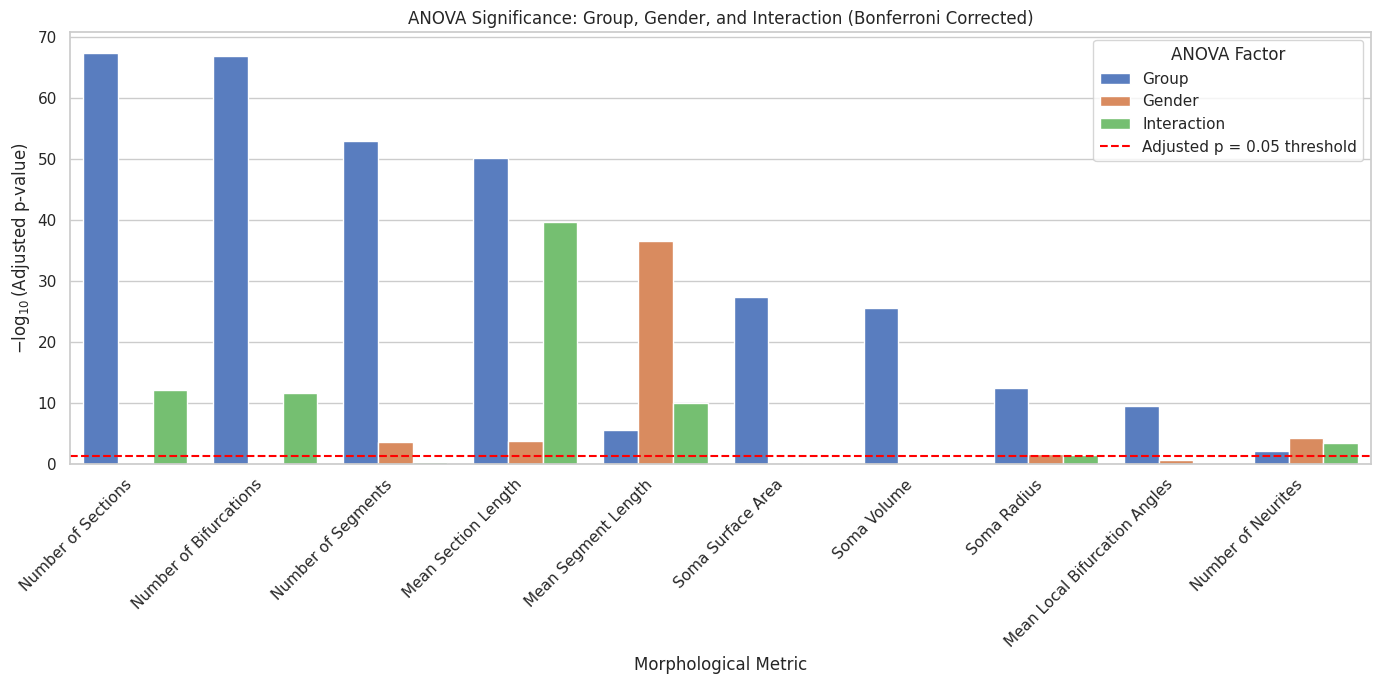

In [111]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Run ANOVA and extract raw p-values
anova_results_interaction = []

# Ensure you use the adult_df_no_outliers (which should now be your Adult-Only cohort)
for metric in metrics:
    # Drop NAs for the specific columns to prevent model errors
    df_temp = adult_df_no_outliers[['group', 'gender', metric]].dropna()

    # Check for sufficient group representation
    if len(df_temp['group'].unique()) >= 2 and \
       len(df_temp['gender'].unique()) >= 2:

        # FIX: Use Q() to properly quote the metric name for the Patsy formula
        # This prevents the "Number of rows mismatch" error
        formula = f'Q("{metric}") ~ C(group) * C(gender)'

        try:
            model = ols(formula, data=df_temp).fit()
            anova_table = sm.stats.anova_lm(model, typ=2)

            anova_results_interaction.append({
                'metric': metric,
                'sum_sq_group': anova_table.loc['C(group)', 'sum_sq'],
                'F_group': anova_table.loc['C(group)', 'F'],
                'p_group_raw': anova_table.loc['C(group)', 'PR(>F)'],

                'sum_sq_gender': anova_table.loc['C(gender)', 'sum_sq'],
                'F_gender': anova_table.loc['C(gender)', 'F'],
                'p_gender_raw': anova_table.loc['C(gender)', 'PR(>F)'],

                'sum_sq_interaction': anova_table.loc['C(group):C(gender)', 'sum_sq'],
                'F_interaction': anova_table.loc['C(group):C(gender)', 'F'],
                'p_interaction_raw': anova_table.loc['C(group):C(gender)', 'PR(>F)']
            })
        except Exception as e:
            print(f"Skipping {metric} due to error: {e}")

# 2. Convert to DataFrame
anova_interaction_df = pd.DataFrame(anova_results_interaction)

# 3. APPLY BONFERRONI CORRECTION (Factor of 20)
correction_factor = 20
for col in ['p_group', 'p_gender', 'p_interaction']:
    raw_col = col + '_raw'
    anova_interaction_df[col] = (anova_interaction_df[raw_col] * correction_factor).clip(upper=1.0)

# Sort and Save
anova_interaction_df = anova_interaction_df.sort_values('p_interaction')
anova_interaction_df.to_csv('anova_interaction_results_corrected.csv', index=False)

# 4. Prepare data for plotting
melted_df = pd.melt(
    anova_interaction_df,
    id_vars=['metric'],
    value_vars=['p_group', 'p_gender', 'p_interaction'],
    var_name='factor',
    value_name='p_corrected'
)

melted_df['factor'] = melted_df['factor'].replace({
    'p_group': 'Group',
    'p_gender': 'Gender',
    'p_interaction': 'Interaction'
})

melted_df['-log10(p_adj)'] = -np.log10(melted_df['p_corrected'].replace(0, 1e-300))
melted_df['metric_clean'] = melted_df['metric'].apply(clean_metric_name)

# 5. Handle plot ordering
metric_order = (anova_interaction_df
                .set_index('metric')[['p_group', 'p_gender', 'p_interaction']]
                .min(axis=1)
                .sort_values()
                .index.tolist())

metric_order_clean = [clean_metric_name(m) for m in metric_order]
melted_df['metric_clean'] = pd.Categorical(melted_df['metric_clean'],
                                           categories=metric_order_clean,
                                           ordered=True)

# 6. Final Visualization
plt.figure(figsize=(14, 7))
sns.barplot(data=melted_df, x='metric_clean', y='-log10(p_adj)', hue='factor', palette='muted')

plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='Adjusted p = 0.05 threshold')
plt.ylabel(r'$-\log_{10}(\text{Adjusted p-value})$')
plt.xlabel('Morphological Metric')
plt.title('ANOVA Significance: Group, Gender, and Interaction (Bonferroni Corrected)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='ANOVA Factor', loc='upper right')
plt.tight_layout()
plt.show()

In [112]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd

def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.std(x, ddof=1) ** 2 + (ny - 1) * np.std(y, ddof=1) ** 2) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

summary_table = []

for metric in metrics:
    for sex in ['Male', 'Female']:
        control_vals = adult_df_no_outliers[(adult_df_no_outliers['group']=='Control') &
                                             (adult_df_no_outliers['gender']==sex)][metric].dropna()
        ad_vals = adult_df_no_outliers[(adult_df_no_outliers['group']=='AD') &
                                        (adult_df_no_outliers['gender']==sex)][metric].dropna()
        if len(control_vals) > 0 and len(ad_vals) > 0:
            t_stat, p_val = ttest_ind(ad_vals, control_vals, equal_var=False)
            pct_change = (ad_vals.mean() - control_vals.mean()) / control_vals.mean() * 100
            d = cohen_d(ad_vals, control_vals)
            summary_table.append({
                'Metric': metric,
                'Sex': sex,
                'Control Mean ± SD': f"{control_vals.mean():.2f} ± {control_vals.std():.2f}",
                'AD Mean ± SD': f"{ad_vals.mean():.2f} ± {ad_vals.std():.2f}",
                '% Change from Control': f"{pct_change:.2f}%",
                't-stat': t_stat,
                'p-value': p_val,
                "Cohen's d": d
            })

summary_df = pd.DataFrame(summary_table)
summary_df

,Metric,Sex,Control Mean ± SD,AD Mean ± SD,% Change from Control,t-stat,p-value,Cohen's d
0,soma_volume,Male,48.73 ± 119.79,14.85 ± 20.12,-69.53%,-8.981212,1.028292e-18,-0.342147
1,soma_volume,Female,44.77 ± 99.66,8.46 ± 17.89,-81.09%,-12.955780,1.725956e-36,-0.440321
2,soma_surface_area,Male,33.34 ± 56.29,18.70 ± 17.55,-43.91%,-7.753265,1.698136e-14,-0.309602
3,soma_surface_area,Female,33.52 ± 53.54,11.83 ± 15.09,-64.72%,-13.792710,3.888086e-41,-0.484312
4,soma_radius,Male,1.23 ± 1.07,1.09 ± 0.54,-11.31%,-3.441356,5.939163e-04,-0.149926
5,soma_radius,Female,1.20 ± 1.11,0.85 ± 0.48,-29.33%,-9.883524,1.618066e-22,-0.368757
6,number_of_neurites,Male,3.28 ± 1.55,3.35 ± 1.48,2.15%,0.876630,3.808854e-01,0.046197
7,number_of_neurites,Female,3.19 ± 1.70,2.79 ± 1.36,-12.75%,-5.768495,9.605177e-09,-0.254460
8,number_of_sections,Male,102.04 ± 66.06,82.04 ± 43.12,-19.60%,-7.209544,9.012449e-13,-0.335698
9,number_of_sections,Female,116.29 ± 66.36,64.17 ± 39.02,-44.81%,-22.029258,4.124191e-96,-0.885375


In [113]:
summary_df.to_csv('baseline_results_table_morpho', index=False)